# Dynamic Compressor Simulation with Good Compressor Maps

This notebook is a Colab-style replacement for the older dynamic compressor example. The process examples are the same kind of compressor, speed-control, and anti-surge studies, but every compressor now uses an explicit multi-speed centrifugal compressor map with:

- head curves by shaft speed,
- polytropic-efficiency islands,
- an implemented surge curve on the low-flow side,
- an implemented stonewall/choke curve on the high-flow side,
- operating-point trajectories plotted back on the map.

The map data below is illustrative vendor-style data. Replace the arrays with vendor-certified points for design work.

In [1]:
import os
import sys
from pathlib import Path

from jpype import JArray, JDouble
import numpy as np
import matplotlib.pyplot as plt


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))

from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
NEQSIM_MODE = "devtools"

SystemSrkEos = ns.SystemSrkEos
ProcessSystem = ns.ProcessSystem
Stream = ns.Stream
Separator = ns.Separator
Compressor = ns.Compressor
Mixer = ns.Mixer
Cooler = ns.Cooler
Splitter = ns.Splitter
ThrottlingValve = ns.ThrottlingValve
Recycle = ns.Recycle
AntiSurgeCalculator = ns.JClass("neqsim.process.equipment.util.AntiSurgeCalculator")
PressureTransmitter = ns.JClass("neqsim.process.measurementdevice.PressureTransmitter")
ControllerDevice = ns.JClass("neqsim.process.controllerdevice.ControllerDeviceBaseClass")

print(f"NeqSim classes imported from workspace via {NEQSIM_MODE}.")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.14.0.jar



JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim classes imported from workspace via devtools.


## 1. Vendor-style compressor map data

The old notebook generated a simple compressor chart from one operating point. Here we define a realistic family of speed curves and load the low-flow and high-flow boundaries explicitly into the compressor chart.

In [2]:
CHART_CONDITIONS = [0.3, 1.0, 1.0, 1.0]
SPEED = [12913, 12298, 11683, 11098, 10453, 9224, 8609, 8200]

FLOW = [
    [2789.13, 3174.04, 3689.23, 4179.45, 4570.28, 4954.77, 5246.03, 5661.03],
    [2571.18, 2943.73, 3440.27, 3837.44, 4253.09, 4668.66, 4997.19, 5387.50],
    [2415.38, 2763.07, 3141.71, 3594.74, 4047.65, 4494.19, 4853.74, 5138.79],
    [2247.20, 2799.73, 3178.34, 3656.16, 4102.78, 4394.16, 4648.32, 4840.50],
    [2072.84, 2463.95, 2836.41, 3202.53, 3599.63, 3978.02, 4257.00, 4517.35],
    [1835.96, 2208.46, 2618.13, 2940.80, 3244.79, 3530.13, 3753.37, 3895.97],
    [1711.34, 1965.88, 2356.94, 2685.92, 3008.52, 3337.29, 3591.51, 3700.00],
    [1636.58, 2002.87, 2338.03, 2642.12, 2896.49, 3113.63, 3274.88, 3411.30],
]

HEAD = [
    [80.04, 78.89, 76.21, 71.87, 67.01, 60.61, 53.05, 39.73],
    [72.21, 71.84, 68.90, 65.83, 60.72, 54.70, 47.27, 35.75],
    [65.16, 64.53, 62.61, 59.16, 54.05, 47.01, 39.20, 31.64],
    [58.62, 56.96, 54.66, 50.45, 44.43, 38.41, 32.91, 28.81],
    [52.33, 51.06, 49.53, 46.33, 42.37, 37.25, 31.49, 25.60],
    [40.66, 39.64, 37.60, 34.66, 30.95, 27.11, 23.27, 20.45],
    [35.27, 34.64, 32.72, 31.06, 27.10, 22.75, 18.01, 15.50],
    [32.19, 31.18, 29.13, 26.83, 23.89, 21.33, 18.77, 16.34],
]

POLY_EFF = [
    [77.2, 79.4, 80.7, 80.5, 79.2, 75.5, 69.6, 58.7],
    [77.0, 79.3, 80.9, 80.7, 79.5, 75.6, 69.7, 60.0],
    [77.0, 79.2, 80.8, 80.7, 78.9, 73.7, 66.3, 57.7],
    [77.1, 80.5, 81.1, 79.6, 75.4, 69.5, 63.8, 58.8],
    [77.0, 79.8, 80.9, 80.6, 78.0, 73.0, 66.6, 59.9],
    [77.5, 80.2, 81.0, 79.6, 76.4, 70.8, 64.6, 60.5],
    [77.8, 80.1, 81.1, 79.9, 76.2, 69.3, 60.9, 55.0],
    [78.1, 80.9, 80.8, 78.9, 75.2, 70.3, 65.6, 61.0],
]

SURGE_FLOW = [row[0] for row in FLOW]
SURGE_HEAD = [row[0] for row in HEAD]
STONEWALL_FLOW = [row[-1] for row in FLOW]
STONEWALL_HEAD = [row[-1] for row in HEAD]
DESIGN_SPEED = 11683.0
SUCTION_P_BARA = 48.0

def jdouble1(values):
    return JArray(JDouble)([float(value) for value in values])


def jdouble2(rows):
    return JArray(JDouble, 2)([jdouble1(row) for row in rows])


print(f"Defined {len(SPEED)} speed lines with {len(FLOW[0])} points each.")

Defined 8 speed lines with 8 points each.


In [3]:
def make_gas(flow_MSm3_day=3.0, t_C=25.0, p_bara=55.0):
    fluid = SystemSrkEos(273.15 + t_C, p_bara)
    fluid.addComponent("methane", 1.1)
    fluid.addComponent("ethane", 0.1)
    fluid.setMixingRule(2)
    fluid.setTotalFlowRate(flow_MSm3_day, "MSm3/day")
    return fluid


def install_good_compressor_map(compressor, speed=DESIGN_SPEED):
    compressor.setUsePolytropicCalc(True)
    compressor.setSpeed(speed)
    chart = compressor.getCompressorChart()
    chart.setCurves(
        jdouble1(CHART_CONDITIONS),
        jdouble1(SPEED),
        jdouble2(FLOW),
        jdouble2(HEAD),
        jdouble2(POLY_EFF),
    )
    chart.setHeadUnit("kJ/kg")
    chart.getSurgeCurve().setCurve(jdouble1(CHART_CONDITIONS), jdouble1(SURGE_FLOW), jdouble1(SURGE_HEAD))
    chart.getStoneWallCurve().setCurve(jdouble1(CHART_CONDITIONS), jdouble1(STONEWALL_FLOW), jdouble1(STONEWALL_HEAD))
    chart.setUseCompressorChart(True)
    return compressor


def smooth_limit(curve, kind="surge", n=200):
    heads = np.linspace(min(curve.getHead()), max(curve.getHead()), n)
    if kind == "surge":
        flows = np.array([curve.getSurgeFlow(float(head)) for head in heads])
    else:
        flows = np.array([curve.getStoneWallFlow(float(head)) for head in heads])
    return flows, heads


def plot_compressor_map(chart=None, operating_points=None, title="Compressor map"):
    fig, ax = plt.subplots(figsize=(10, 7))
    flat_flow = np.array([value for row in FLOW for value in row])
    flat_head = np.array([value for row in HEAD for value in row])
    flat_eff = np.array([value for row in POLY_EFF for value in row])

    for i, speed in enumerate(SPEED):
        color = plt.cm.viridis(i / max(len(SPEED) - 1, 1))
        ax.plot(FLOW[i], HEAD[i], "-o", color=color, ms=3, lw=1.5, label=f"{speed:.0f} rpm")

    contour = ax.tricontour(flat_flow, flat_head, flat_eff, levels=[60, 65, 70, 75, 78, 80, 81], colors="0.25", linewidths=0.7)
    ax.clabel(contour, fmt="%1.0f%%", fontsize=8)

    if chart is not None:
        surge_curve = chart.getSurgeCurve()
        stonewall_curve = chart.getStoneWallCurve()
        surge_q, surge_h = smooth_limit(surge_curve, "surge")
        wall_q, wall_h = smooth_limit(stonewall_curve, "stonewall")
        ax.plot(surge_q, surge_h, "r--", lw=2.5, label="Surge curve")
        ax.plot(surge_curve.getFlow(), surge_curve.getHead(), "rx", ms=8, mew=2, label="Surge points")
        ax.plot(wall_q, wall_h, "b--", lw=2.5, label="Stonewall curve")
        ax.plot(stonewall_curve.getFlow(), stonewall_curve.getHead(), "bx", ms=8, mew=2, label="Stonewall points")
        ax.fill_betweenx(surge_h, 0, surge_q, color="red", alpha=0.08)
        ax.fill_betweenx(wall_h, wall_q, 6500, color="blue", alpha=0.08)

    if operating_points:
        q = [point["flow_m3hr"] for point in operating_points]
        h = [point["head_kJkg"] for point in operating_points]
        c = [point.get("color", index) for index, point in enumerate(operating_points)]
        sc = ax.scatter(q, h, c=c, cmap="plasma", s=80, edgecolor="k", zorder=5, label="Operating trajectory")
        if len(set(c)) > 1:
            plt.colorbar(sc, ax=ax, label="trajectory index or feed rate")

    ax.set_xlabel("Actual inlet volumetric flow [m3/hr]")
    ax.set_ylabel("Polytropic head [kJ/kg]")
    ax.set_title(title)
    ax.set_xlim(1400, 6000)
    ax.set_ylim(10, 85)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", ncol=2, fontsize=8)
    plt.tight_layout()
    return fig, ax


print("Map installation and plotting helpers defined.")

Map installation and plotting helpers defined.


## 2. Prove the curves are implemented

This creates one compressor, runs it, and reads the active surge and stonewall curves back from the NeqSim compressor object. The plotted boundaries are therefore the same boundaries used by the compressor diagnostics.

Inlet flow             : 2637.7 m3/hr
Polytropic head        : 64.71 kJ/kg
Polytropic efficiency  : 79.3 %
Outlet pressure        : 76.6 bara
Surge curve active     : True
Stonewall curve active : True
Distance to surge      : 9.7 %
Distance to stonewall  : 179.7 %


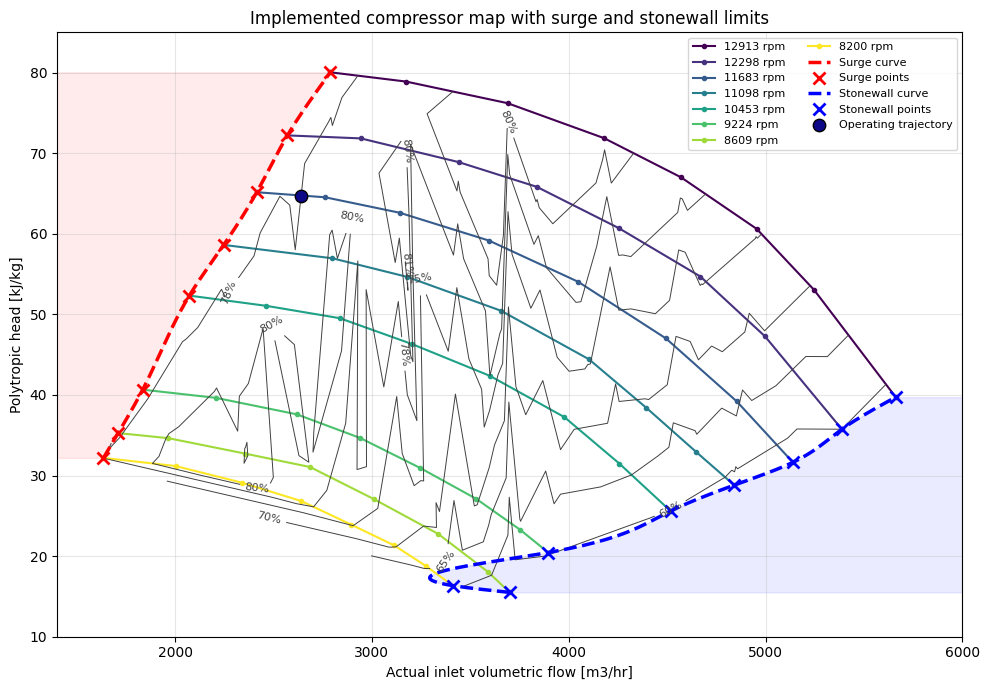

In [4]:
demo_stream = Stream("demo suction", make_gas(3.2, p_bara=SUCTION_P_BARA))
demo_stream.run()
demo_comp = Compressor("demo compressor", demo_stream)
install_good_compressor_map(demo_comp)
demo_comp.run()
demo_chart = demo_comp.getCompressorChart()

print(f"Inlet flow             : {demo_comp.getInletStream().getFlowRate('m3/hr'):.1f} m3/hr")
print(f"Polytropic head        : {demo_comp.getPolytropicFluidHead():.2f} kJ/kg")
print(f"Polytropic efficiency  : {demo_comp.getPolytropicEfficiency() * 100.0:.1f} %")
print(f"Outlet pressure        : {demo_comp.getOutletStream().getPressure('bara'):.1f} bara")
print(f"Surge curve active     : {demo_chart.getSurgeCurve().isActive()}")
print(f"Stonewall curve active : {demo_chart.getStoneWallCurve().isActive()}")
print(f"Distance to surge      : {demo_comp.getDistanceToSurge() * 100.0:.1f} %")
print(f"Distance to stonewall  : {demo_comp.getDistanceToStoneWall() * 100.0:.1f} %")

plot_compressor_map(
    demo_chart,
    operating_points=[{
        "flow_m3hr": demo_comp.getInletStream().getFlowRate("m3/hr"),
        "head_kJkg": demo_comp.getPolytropicFluidHead(),
        "color": 0,
    }],
    title="Implemented compressor map with surge and stonewall limits",
)
plt.show()

## 3. Mapped operating trajectory: speed step

The first transient attempt used gas inventory vessels and pressure valves without a stable downstream boundary, which can drive the model to vacuum and unrealistically large actual volume flows. This replacement keeps the compressor-map physics as the focus: each time point is a bounded operating point solved with the same implemented chart, surge curve, and stonewall curve.

In [5]:
def run_mapped_compressor_case(feed_flow_MSm3_day=3.2, speed=DESIGN_SPEED, suction_p_bara=SUCTION_P_BARA):
    stream = Stream("mapped suction", make_gas(feed_flow_MSm3_day, t_C=25.0, p_bara=suction_p_bara))
    stream.run()
    compressor = Compressor("mapped compressor case", stream)
    install_good_compressor_map(compressor, speed=speed)
    compressor.run()
    return {
        "feed_flow_MSm3_day": feed_flow_MSm3_day,
        "speed_rpm": compressor.getSpeed(),
        "suction_pressure_bara": compressor.getInletStream().getPressure("bara"),
        "outlet_pressure_bara": compressor.getOutletStream().getPressure("bara"),
        "flow_m3hr": compressor.getInletStream().getFlowRate("m3/hr"),
        "head_kJkg": compressor.getPolytropicFluidHead(),
        "efficiency_pct": compressor.getPolytropicEfficiency() * 100.0,
        "surge_margin_pct": compressor.getDistanceToSurge() * 100.0,
        "stonewall_margin_pct": compressor.getDistanceToStoneWall() * 100.0,
        "chart": compressor.getCompressorChart(),
    }


time_s = np.arange(0, 360, 10)
speed_profile = np.where(time_s < 120, 11098.0, 11098.0 + (12298.0 - 11098.0) * (1.0 - np.exp(-(time_s - 120) / 80.0)))
speed_profile = np.minimum(speed_profile, 12250.0)

speed_cases = [run_mapped_compressor_case(speed=float(speed)) for speed in speed_profile]
psuc = [case["suction_pressure_bara"] for case in speed_cases]
pdis = [case["outlet_pressure_bara"] for case in speed_cases]
flow = [case["flow_m3hr"] for case in speed_cases]
head = [case["head_kJkg"] for case in speed_cases]
speed = [case["speed_rpm"] for case in speed_cases]
surge_margin = [case["surge_margin_pct"] for case in speed_cases]
stonewall_margin = [case["stonewall_margin_pct"] for case in speed_cases]
comp1_chart = speed_cases[-1]["chart"]

print(f"Initial outlet pressure : {pdis[0]:.2f} bara")
print(f"Final outlet pressure   : {pdis[-1]:.2f} bara")
print(f"Final flow              : {flow[-1]:.1f} m3/hr")
print(f"Final surge margin      : {surge_margin[-1]:.1f} %")
print(f"Final stonewall margin  : {stonewall_margin[-1]:.1f} %")

Initial outlet pressure : 73.23 bara
Final outlet pressure   : 80.02 bara
Final flow              : 2637.7 m3/hr
Final surge margin      : 3.6 %
Final stonewall margin  : 196.4 %


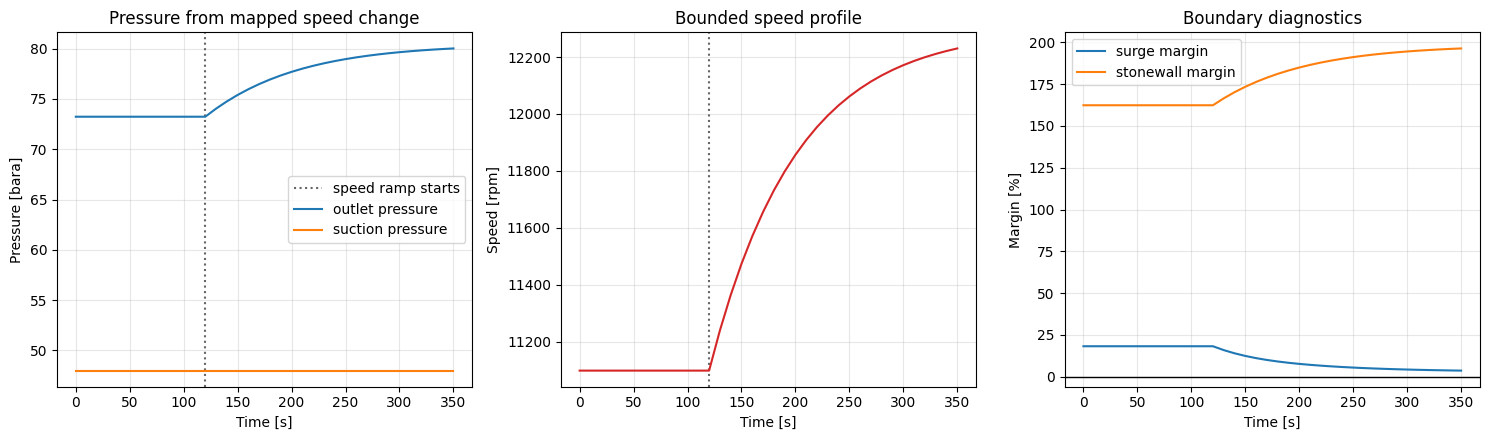

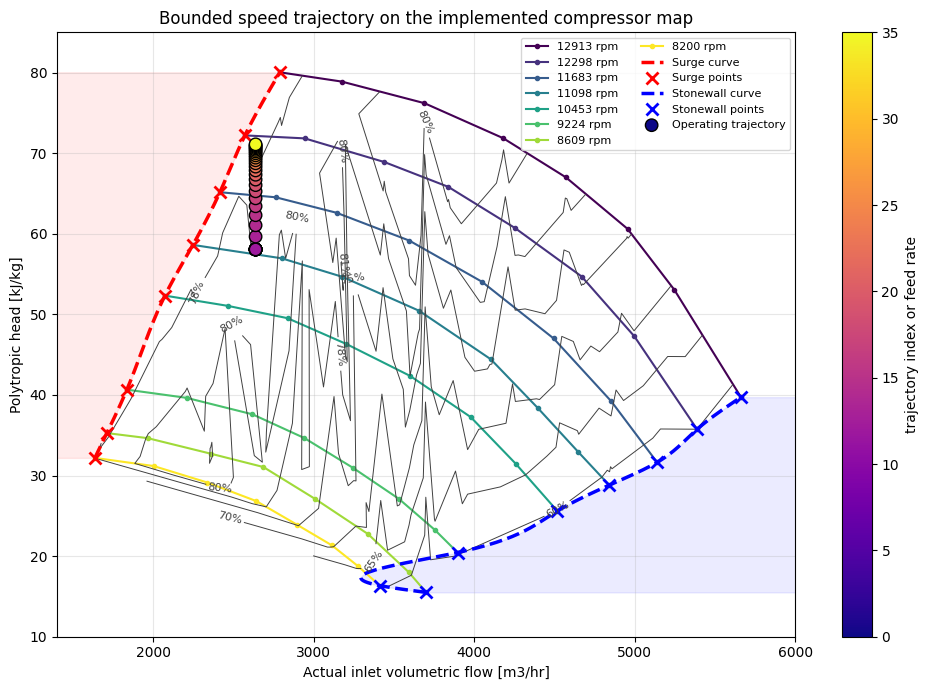

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))
ax[0].axvline(120, color="0.4", ls=":", label="speed ramp starts")
ax[0].plot(time_s, pdis, label="outlet pressure")
ax[0].plot(time_s, psuc, label="suction pressure")
ax[0].set_xlabel("Time [s]")
ax[0].set_ylabel("Pressure [bara]")
ax[0].set_title("Pressure from mapped speed change")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].axvline(120, color="0.4", ls=":")
ax[1].plot(time_s, speed, color="tab:red")
ax[1].set_xlabel("Time [s]")
ax[1].set_ylabel("Speed [rpm]")
ax[1].set_title("Bounded speed profile")
ax[1].grid(True, alpha=0.3)

ax[2].plot(time_s, surge_margin, label="surge margin")
ax[2].plot(time_s, stonewall_margin, label="stonewall margin")
ax[2].axhline(0.0, color="k", lw=1)
ax[2].set_xlabel("Time [s]")
ax[2].set_ylabel("Margin [%]")
ax[2].set_title("Boundary diagnostics")
ax[2].legend()
ax[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

trajectory = [
    {"flow_m3hr": q, "head_kJkg": h, "color": i}
    for i, (q, h) in enumerate(zip(flow, head))
    if np.isfinite(q) and np.isfinite(h)
]
plot_compressor_map(comp1_chart, trajectory, "Bounded speed trajectory on the implemented compressor map")
plt.show()

## 4. Mapped operating trajectory: flow turndown

At fixed speed, reducing feed demand moves the operating point left toward surge. This is the clean diagnostic view that the anti-surge recycle section uses next: below the surge line, recycle must add suction flow to keep the compressor out of surge.

In [7]:
flow_profile = np.r_[
    np.linspace(4.1, 3.2, 8),
    np.linspace(3.2, 2.6, 8),
    np.linspace(2.6, 3.8, 10),
]
flow_cases = [run_mapped_compressor_case(feed_flow_MSm3_day=float(feed_flow), speed=DESIGN_SPEED) for feed_flow in flow_profile]

t2 = np.arange(len(flow_cases)) * 10.0
feed_demand = [case["feed_flow_MSm3_day"] for case in flow_cases]
p_out2 = [case["outlet_pressure_bara"] for case in flow_cases]
flow2 = [case["flow_m3hr"] for case in flow_cases]
head2 = [case["head_kJkg"] for case in flow_cases]
surge_margin2 = [case["surge_margin_pct"] for case in flow_cases]
stonewall_margin2 = [case["stonewall_margin_pct"] for case in flow_cases]
comp2_chart = flow_cases[-1]["chart"]

print(f"Lowest demand              : {min(feed_demand):.2f} MSm3/day")
print(f"Minimum surge margin       : {min(surge_margin2):.1f} %")
print(f"Outlet pressure range      : {min(p_out2):.1f} to {max(p_out2):.1f} bara")
print(f"Stonewall margin range     : {min(stonewall_margin2):.1f} to {max(stonewall_margin2):.1f} %")

Lowest demand              : 2.60 MSm3/day
Minimum surge margin       : -10.8 %
Outlet pressure range      : 74.6 to 76.7 bara
Stonewall margin range     : 110.0 to 243.7 %


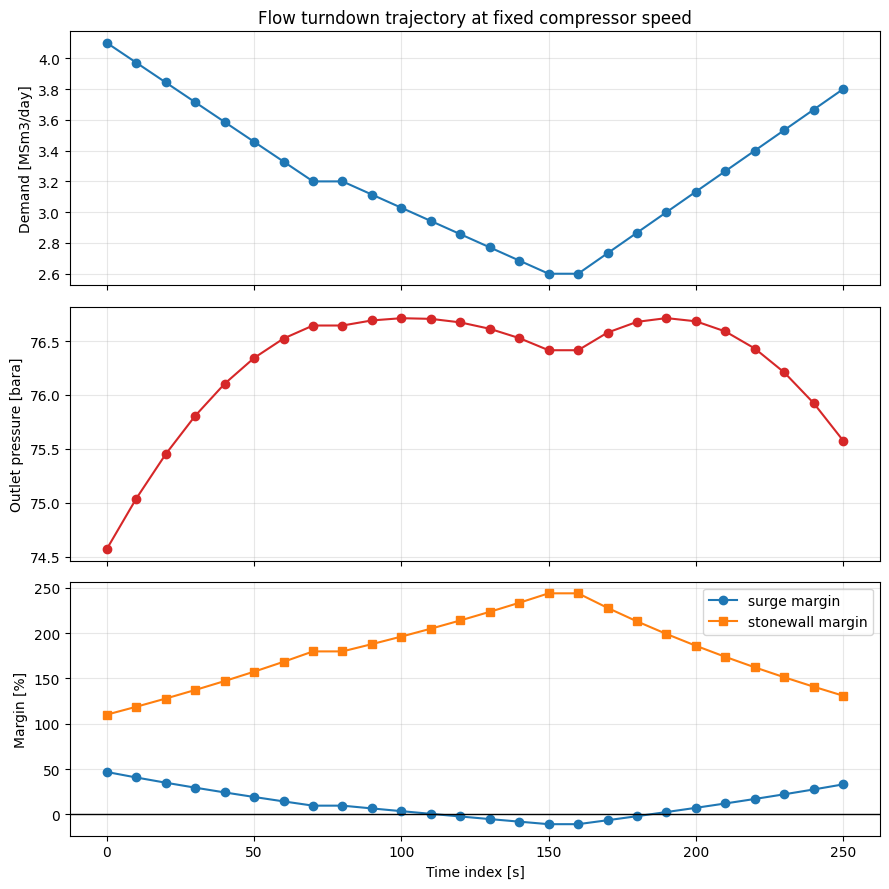

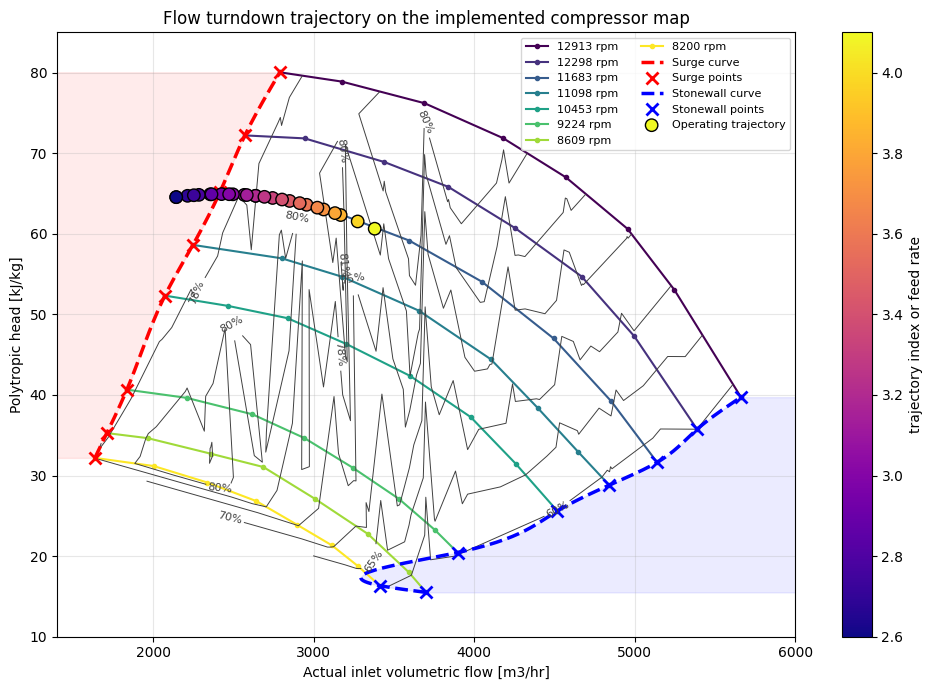

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
ax[0].plot(t2, feed_demand, marker="o")
ax[0].set_ylabel("Demand [MSm3/day]")
ax[0].set_title("Flow turndown trajectory at fixed compressor speed")
ax[0].grid(True, alpha=0.3)

ax[1].plot(t2, p_out2, color="tab:red", marker="o")
ax[1].set_ylabel("Outlet pressure [bara]")
ax[1].grid(True, alpha=0.3)

ax[2].plot(t2, surge_margin2, label="surge margin", marker="o")
ax[2].plot(t2, stonewall_margin2, label="stonewall margin", marker="s")
ax[2].axhline(0.0, color="k", lw=1)
ax[2].set_ylabel("Margin [%]")
ax[2].set_xlabel("Time index [s]")
ax[2].legend()
ax[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

control_trajectory = [
    {"flow_m3hr": q, "head_kJkg": h, "color": demand}
    for q, h, demand in zip(flow2, head2, feed_demand)
    if np.isfinite(q) and np.isfinite(h)
]
plot_compressor_map(comp2_chart, control_trajectory, "Flow turndown trajectory on the implemented compressor map")
plt.show()

## 5. Anti-surge recycle sweep

This section closes a recycle loop around the mapped compressor. The `AntiSurgeCalculator` reads the same implemented surge curve used in the plots, opens recycle at deep turndown, and keeps the compressor suction flow close to the surge boundary instead of crossing it.

In [9]:
def build_antisurge_process(feed_flow_MSm3_day):
    process = ProcessSystem()

    feed = Stream("feed gas demand", make_gas(feed_flow_MSm3_day, t_C=24.0, p_bara=SUCTION_P_BARA))
    feed.run()
    process.add(feed)

    recycle_gas = Stream("anti surge recycle gas", feed.getThermoSystem().clone())
    recycle_gas.setFlowRate(1.0, "kg/hr")
    recycle_gas.run()
    process.add(recycle_gas)

    mixer = Mixer("suction mixer")
    mixer.addStream(feed)
    mixer.addStream(recycle_gas)
    mixer.run()
    process.add(mixer)

    cooler = Cooler("suction cooler")
    cooler.setInletStream(mixer.getOutletStream())
    cooler.setOutTemperature(24.0, "C")
    cooler.run()
    process.add(cooler)

    comp = Compressor("anti surge mapped compressor", cooler.getOutletStream())
    comp.setOutletPressure(95.0, "bara")
    install_good_compressor_map(comp)
    comp.run()
    process.add(comp)

    splitter = Splitter("anti surge splitter", comp.getOutletStream(), 2)
    splitter.setFlowRates([-1.0, 1.0], "kg/hr")
    splitter.run()
    process.add(splitter)

    calc = AntiSurgeCalculator("anti surge calculator", comp, splitter)
    calc.run()
    process.add(calc)

    valve = ThrottlingValve("anti surge valve", splitter.getSplitStream(1))
    valve.setOutletPressure(SUCTION_P_BARA, "bara")
    valve.run()
    process.add(valve)

    recycle = Recycle("anti surge recycle")
    recycle.addStream(valve.getOutletStream())
    recycle.setOutletStream(recycle_gas)
    recycle.setTolerance(1.0e-3)
    recycle.run()
    process.add(recycle)

    process.run()
    return {
        "process": process,
        "feed": feed,
        "recycle_gas": recycle_gas,
        "compressor": comp,
        "splitter": splitter,
        "valve": valve,
        "recycle": recycle,
    }


print("Anti-surge recycle process builder defined.")

Anti-surge recycle process builder defined.


In [10]:
demands = [0.30, 0.45, 0.60, 0.80, 1.10, 1.50, 2.00, 2.60, 3.20, 3.80]
sweep = []
last_model = None

for demand in demands:
    model = build_antisurge_process(demand)
    last_model = model
    comp = model["compressor"]
    feed = model["feed"]
    recycle_gas = model["recycle_gas"]
    splitter = model["splitter"]
    sweep.append({
        "demand_MSm3_day": demand,
        "feed_kg_hr": feed.getFlowRate("kg/hr"),
        "recycle_kg_hr": recycle_gas.getFlowRate("kg/hr"),
        "forward_kg_hr": splitter.getSplitStream(0).getFlowRate("kg/hr"),
        "suction_flow_m3hr": comp.getInletStream().getFlowRate("m3/hr"),
        "surge_flow_m3hr": comp.getSurgeFlowRate(),
        "head_kJkg": comp.getPolytropicFluidHead(),
        "surge_margin_pct": comp.getDistanceToSurge() * 100.0,
        "stonewall_margin_pct": comp.getDistanceToStoneWall() * 100.0,
    })

print("Demand  Recycle kg/hr  Surge margin %  Stonewall margin %")
for row in sweep:
    print(f"{row['demand_MSm3_day']:6.2f} {row['recycle_kg_hr']:14.0f} {row['surge_margin_pct']:15.1f} {row['stonewall_margin_pct']:18.1f}")

Demand  Recycle kg/hr  Surge margin %  Stonewall margin %
  0.30          80008            -0.0              206.7
  0.45          75459            -0.0              206.7
  0.60          70909             0.0              206.7
  0.80          64843             0.0              206.7
  1.10          55744             0.0              206.7
  1.50          43611            -0.0              206.7
  2.00          28446            -0.0              206.7
  2.60          10248            -0.0              206.7
  3.20              0             9.1              181.1
  3.80              0            32.3              132.2


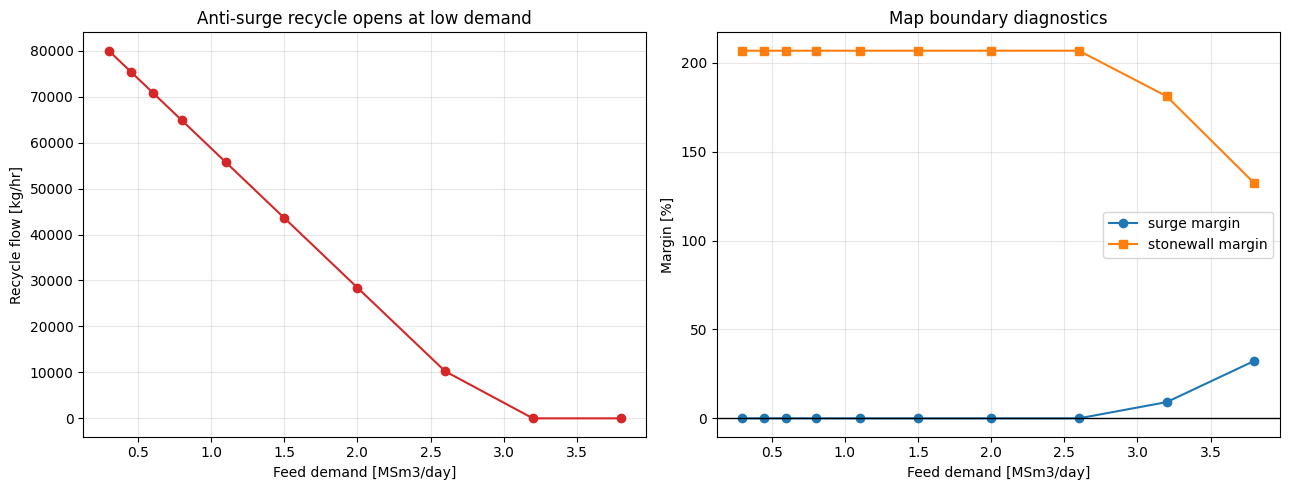

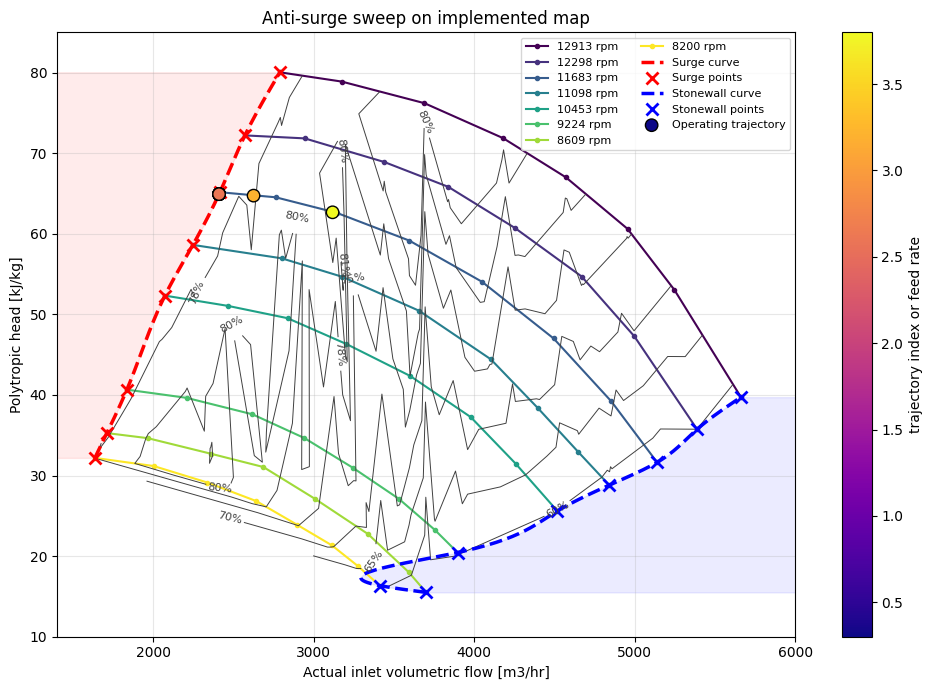

In [11]:
demand = np.array([row["demand_MSm3_day"] for row in sweep])
recycle_flow = np.array([row["recycle_kg_hr"] for row in sweep])
surge_margin = np.array([row["surge_margin_pct"] for row in sweep])
stonewall_margin = np.array([row["stonewall_margin_pct"] for row in sweep])

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(demand, recycle_flow, "o-", color="tab:red")
ax[0].set_xlabel("Feed demand [MSm3/day]")
ax[0].set_ylabel("Recycle flow [kg/hr]")
ax[0].set_title("Anti-surge recycle opens at low demand")
ax[0].grid(True, alpha=0.3)

ax[1].plot(demand, surge_margin, "o-", label="surge margin")
ax[1].plot(demand, stonewall_margin, "s-", label="stonewall margin")
ax[1].axhline(0.0, color="k", lw=1)
ax[1].set_xlabel("Feed demand [MSm3/day]")
ax[1].set_ylabel("Margin [%]")
ax[1].set_title("Map boundary diagnostics")
ax[1].legend()
ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sweep_points = [
    {"flow_m3hr": row["suction_flow_m3hr"], "head_kJkg": row["head_kJkg"], "color": row["demand_MSm3_day"]}
    for row in sweep
]
plot_compressor_map(last_model["compressor"].getCompressorChart(), sweep_points, "Anti-surge sweep on implemented map")
plt.show()

## 6. Dynamic anti-surge response with a GOOD map

This dynamic case uses the same mapped compressor and a Colab-style anti-surge recycle loop. The inlet valve is ramped from 50% to 20% opening over 120 seconds and then ramped back up. A hard one-step closure can push the mapped compressor left of the surge line before the recycle loop has time to respond; the ramped disturbance keeps the example focused on the controller behavior rather than on deep-surge recovery.

The pressure-controlled transient can move outside the plotted vendor-map window, so this section now shows both views: an autoscaled Colab-style operating trajectory in flow-head coordinates, and the same points overlaid on the implemented compressor map where the map range permits.

A small discharge-pressure speed controller is included so the operating point does not simply follow one constant-speed line. The pressure controller moves the compressor speed with a rate limit, while the anti-surge controller opens recycle when the operating point approaches the surge line.

In [12]:
CompressorMonitor = ns.JClass("neqsim.process.measurementdevice.CompressorMonitor")
SetPoint = ns.JClass("neqsim.process.equipment.util.SetPoint")


def build_dynamic_antisurge_process():
    fluid = make_gas(4.5, t_C=25.0, p_bara=60.0)
    stream1 = Stream("dynamic feed gas", fluid)
    stream1.setFlowRate(4.5, "MSm3/day")
    stream1.setPressure(60.0, "bara")
    stream1.setTemperature(25.0, "C")

    valve1 = ThrottlingValve("dynamic inlet valve", stream1)
    valve1.setOutletPressure(48.0, "bara")
    valve1.setPercentValveOpening(50.0)
    valve1.setCalculateSteadyState(False)

    recycle_stream = stream1.clone()
    recycle_stream.setName("dynamic recycle stream")
    recycle_stream.setFlowRate(0.01, "MSm3/day")

    separator1 = Separator("dynamic suction separator")
    separator1.setCalculateSteadyState(False)
    separator1.setSeparatorLength(22.0)
    separator1.setInternalDiameter(1.6)
    separator1.setLiquidLevel(0.0)
    separator1.addStream(valve1.getOutletStream())
    separator1.addStream(recycle_stream)

    compressor = Compressor("dynamic mapped compressor", separator1.getGasOutStream())
    compressor.setCalculateSteadyState(False)
    compressor.setOutletPressure(90.0, "bara")

    surge_monitor = CompressorMonitor(compressor)
    surge_monitor.setMinimumValue(-5.0)
    surge_monitor.setMaximumValue(5.0)

    aftercooler = Cooler("dynamic after cooler", compressor.getOutletStream())
    aftercooler.setOutTemperature(30.0, "C")
    aftercooler.setCalculateSteadyState(False)

    separator2 = Separator("dynamic discharge separator")
    separator2.setCalculateSteadyState(False)
    separator2.setSeparatorLength(15.0)
    separator2.setInternalDiameter(1.0)
    separator2.setLiquidLevel(0.0)
    separator2.addStream(aftercooler.getOutletStream())

    gas_from_sep2 = Stream("dynamic gas from sep", separator2.getGasOutStream())
    splitter = Splitter("dynamic anti-surge splitter", gas_from_sep2)
    splitter.setSplitFactors([0.99, 0.01])
    splitter.setCalculateSteadyState(False)

    recycle_valve = ThrottlingValve("dynamic anti-surge valve", splitter.getSplitStream(1))
    recycle_valve.setOutletPressure(50.0, "bara")
    recycle_valve.setCalculateSteadyState(False)
    recycle_valve.setMinimumValveOpening(1.0)
    recycle_valve.setPercentValveOpening(2.0)

    pressure_set = SetPoint(
        "dynamic anti-surge valve pressure set",
        recycle_valve,
        "pressure",
        separator1.getGasOutStream(),
    )

    recycle = Recycle("dynamic anti-surge recycle")
    recycle.addStream(recycle_valve.getOutletStream())
    recycle.setOutletStream(recycle_stream)
    recycle.setTolerance(1.0e-4)

    outlet_valve = ThrottlingValve("dynamic outlet valve", splitter.getSplitStream(0))
    outlet_valve.setOutletPressure(52.0, "bara")
    outlet_valve.setPercentValveOpening(50.0)
    outlet_valve.setCalculateSteadyState(False)
    outlet_valve.setMinimumValveOpening(1.0)

    surge_controller = ControllerDevice()
    surge_controller.setReverseActing(True)
    surge_controller.setTransmitter(surge_monitor)
    surge_controller.setControllerSetPoint(0.8)
    surge_controller.setControllerParameters(2.0, 200.0, 0.0)
    surge_controller.setActive(True)

    process = ProcessSystem()
    for unit in [
        stream1,
        recycle_stream,
        valve1,
        separator1,
        compressor,
        surge_monitor,
        aftercooler,
        separator2,
        gas_from_sep2,
        splitter,
        pressure_set,
        recycle_valve,
        recycle,
        outlet_valve,
    ]:
        process.add(unit)

    recycle_valve.setController(surge_controller)
    process.run()
    recycle_valve.setCv(outlet_valve.getCv())
    install_good_compressor_map(compressor)
    process.run()

    return {
        "process": process,
        "feed_valve": valve1,
        "compressor": compressor,
        "surge_monitor": surge_monitor,
        "recycle_valve": recycle_valve,
        "separator1": separator1,
    }


model = build_dynamic_antisurge_process()
process = model["process"]
feed_valve = model["feed_valve"]
compressor = model["compressor"]
surge_monitor = model["surge_monitor"]
recycle_valve = model["recycle_valve"]
separator1 = model["separator1"]

speed_controller = {"integral": 0.0}
speed_pressure_setpoint_bara = 90.0
minimum_speed_rpm = 10453.0
maximum_speed_rpm = 12298.0
maximum_speed_rate_rpm_s = 12.0
speed_proportional_gain_rpm_per_bar = 55.0
speed_integral_gain_rpm_per_bar_s = 0.18


def apply_pressure_speed_control(dt_s):
    discharge_pressure = compressor.getOutletStream().getPressure("bara")
    pressure_error = speed_pressure_setpoint_bara - discharge_pressure
    speed_controller["integral"] += pressure_error * dt_s
    unconstrained_target = (
        DESIGN_SPEED
        + speed_proportional_gain_rpm_per_bar * pressure_error
        + speed_integral_gain_rpm_per_bar_s * speed_controller["integral"]
    )
    target_speed = float(np.clip(unconstrained_target, minimum_speed_rpm, maximum_speed_rpm))
    current_speed = compressor.getSpeed()
    maximum_step = maximum_speed_rate_rpm_s * dt_s
    new_speed = current_speed + float(np.clip(target_speed - current_speed, -maximum_step, maximum_step))
    compressor.setSpeed(new_speed)
    return target_speed, discharge_pressure

history = []


def record(time_s, phase):
    history.append({
        "time_s": float(time_s),
        "phase": phase,
        "inlet_opening_pct": feed_valve.getPercentValveOpening(),
        "compressor_flow_m3hr": compressor.getInletStream().getFlowRate("m3/hr"),
        "head_kJkg": compressor.getPolytropicFluidHead(),
        "surge_margin": surge_monitor.getMeasuredValue("distance to surge"),
        "recycle_opening_pct": recycle_valve.getPercentValveOpening(),
        "recycle_flow_m3hr": recycle_valve.getOutletStream().getFlowRate("m3/hr"),
        "suction_pressure_bara": separator1.getPressure(),
        "discharge_pressure_bara": compressor.getOutletStream().getPressure("bara"),
        "speed_rpm": compressor.getSpeed(),
    })


record(0.0, "initial")
process.setTimeStep(1.0)
for step in range(30):
    apply_pressure_speed_control(1.0)
    process.runTransient()
    record(step + 1.0, "base")

for step in range(120):
    feed_valve.setPercentValveOpening(50.0 - 30.0 * (step + 1) / 120.0)
    apply_pressure_speed_control(1.0)
    process.runTransient()
    record(31.0 + step, "closing")

for step in range(120):
    feed_valve.setPercentValveOpening(20.0 + 30.0 * (step + 1) / 120.0)
    apply_pressure_speed_control(1.0)
    process.runTransient()
    record(151.0 + step, "opening")

surge_trace = np.array([row["surge_margin"] for row in history])
recycle_trace = np.array([row["recycle_flow_m3hr"] for row in history])
minimum_surge_margin = float(np.min(surge_trace))
maximum_recycle_opening = max(row["recycle_opening_pct"] for row in history)

print(f"Minimum distance to surge : {minimum_surge_margin:.4f}")
print(f"Maximum recycle opening   : {maximum_recycle_opening:.1f} %")
print(f"Final distance to surge   : {history[-1]['surge_margin']:.3f}")
print(f"Final recycle flow        : {history[-1]['recycle_flow_m3hr']:.1f} m3/hr")
print(f"Speed range               : {min(row['speed_rpm'] for row in history):.0f} to {max(row['speed_rpm'] for row in history):.0f} rpm")

assert minimum_surge_margin >= 0.0
assert np.isfinite(recycle_trace).all()
assert maximum_recycle_opening > 5.0
assert max(row['speed_rpm'] for row in history) - min(row['speed_rpm'] for row in history) > 100.0

Minimum distance to surge : 0.1471
Maximum recycle opening   : 29.2 %
Final distance to surge   : 1.603
Final recycle flow        : 88.6 m3/hr
Speed range               : 11503 to 12298 rpm


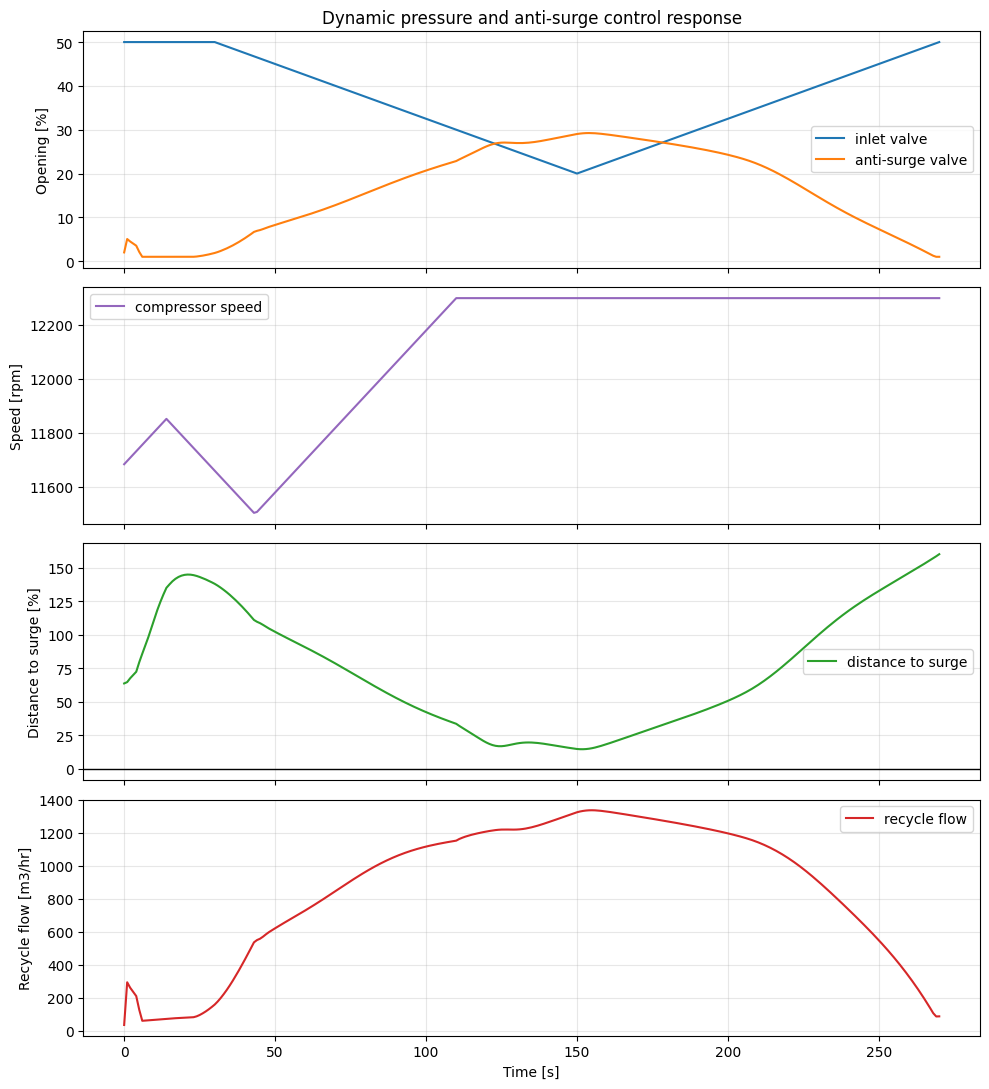

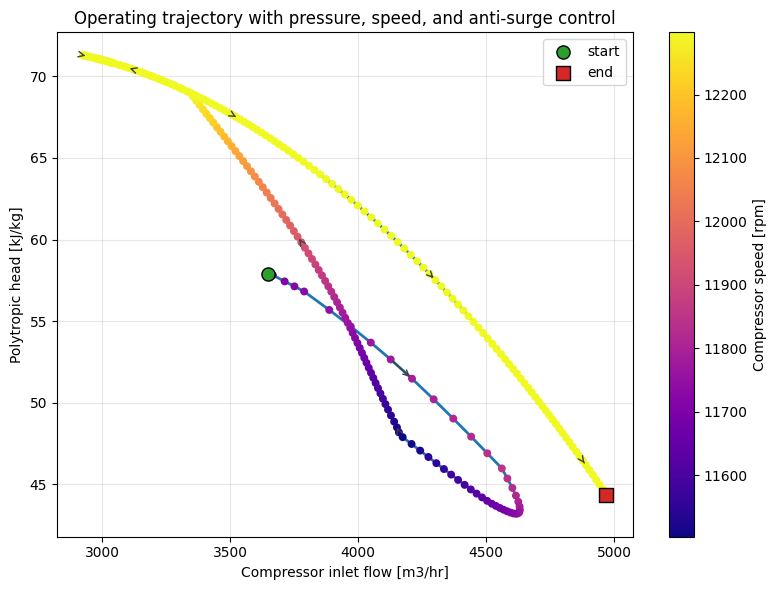

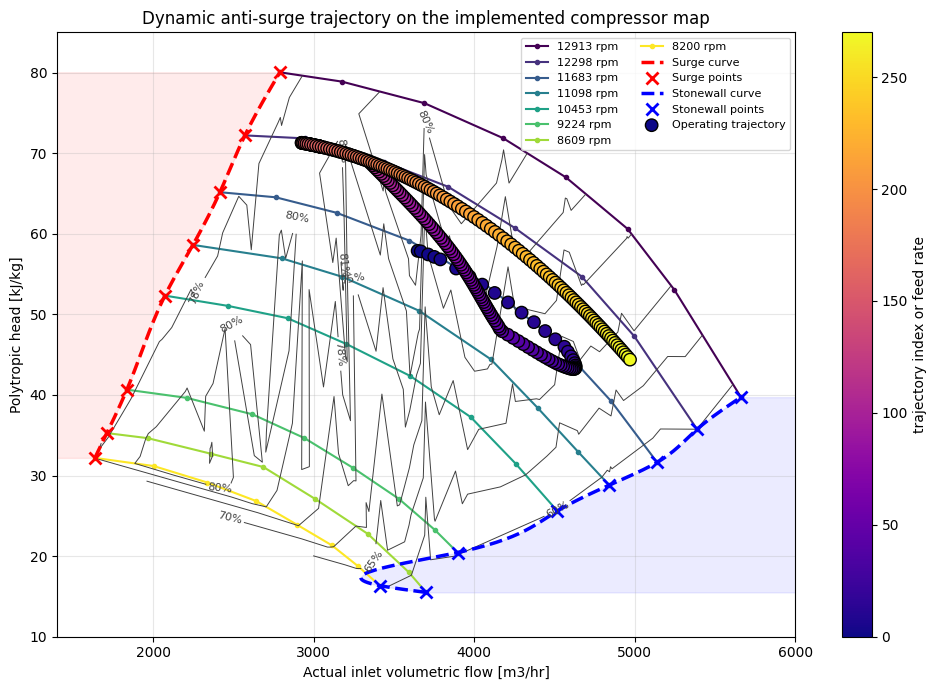

In [13]:
time_dyn = np.array([row["time_s"] for row in history])
feed_opening = np.array([row["inlet_opening_pct"] for row in history])
recycle_opening = np.array([row["recycle_opening_pct"] for row in history])
surge_margin_dyn = np.array([row["surge_margin"] * 100.0 for row in history])
recycle_flow_dyn = np.array([row["recycle_flow_m3hr"] for row in history])
flow_dyn = np.array([row["compressor_flow_m3hr"] for row in history])
head_dyn = np.array([row["head_kJkg"] for row in history])
speed_dyn = np.array([row["speed_rpm"] for row in history])
discharge_pressure_dyn = np.array([row["discharge_pressure_bara"] for row in history])
finite_dyn = np.isfinite(flow_dyn) & np.isfinite(head_dyn)

fig, ax = plt.subplots(4, 1, figsize=(10, 11), sharex=True)
ax[0].plot(time_dyn, feed_opening, label="inlet valve")
ax[0].plot(time_dyn, recycle_opening, label="anti-surge valve")
ax[0].set_ylabel("Opening [%]")
ax[0].set_title("Dynamic pressure and anti-surge control response")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(time_dyn, speed_dyn, color="tab:purple", label="compressor speed")
ax[1].set_ylabel("Speed [rpm]")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(time_dyn, surge_margin_dyn, color="tab:green", label="distance to surge")
ax[2].axhline(0.0, color="k", lw=1)
ax[2].set_ylabel("Distance to surge [%]")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

ax[3].plot(time_dyn, recycle_flow_dyn, color="tab:red", label="recycle flow")
ax[3].set_xlabel("Time [s]")
ax[3].set_ylabel("Recycle flow [m3/hr]")
ax[3].legend()
ax[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(flow_dyn[finite_dyn], head_dyn[finite_dyn], color="tab:blue", lw=2.0)
points = ax.scatter(
    flow_dyn[finite_dyn],
    head_dyn[finite_dyn],
    c=speed_dyn[finite_dyn],
    cmap="plasma",
    s=22,
    zorder=3,
)
ax.scatter(flow_dyn[finite_dyn][0], head_dyn[finite_dyn][0], marker="o", s=90, color="tab:green", edgecolor="k", label="start", zorder=4)
ax.scatter(flow_dyn[finite_dyn][-1], head_dyn[finite_dyn][-1], marker="s", s=90, color="tab:red", edgecolor="k", label="end", zorder=4)
for idx in np.linspace(8, max(len(flow_dyn[finite_dyn]) - 8, 9), 8, dtype=int):
    dx = flow_dyn[finite_dyn][idx + 1] - flow_dyn[finite_dyn][idx]
    dy = head_dyn[finite_dyn][idx + 1] - head_dyn[finite_dyn][idx]
    if np.isfinite(dx) and np.isfinite(dy):
        ax.annotate("", xy=(flow_dyn[finite_dyn][idx + 1], head_dyn[finite_dyn][idx + 1]), xytext=(flow_dyn[finite_dyn][idx], head_dyn[finite_dyn][idx]), arrowprops={"arrowstyle": "->", "color": "0.25", "lw": 1.0})
plt.colorbar(points, ax=ax, label="Compressor speed [rpm]")
ax.set_xlabel("Compressor inlet flow [m3/hr]")
ax.set_ylabel("Polytropic head [kJ/kg]")
ax.set_title("Operating trajectory with pressure, speed, and anti-surge control")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

trajectory_dyn = [
    {"flow_m3hr": float(q), "head_kJkg": float(h), "color": float(t)}
    for q, h, t in zip(flow_dyn, head_dyn, time_dyn)
    if np.isfinite(q) and np.isfinite(h)
]
plot_compressor_map(
    compressor.getCompressorChart(),
    trajectory_dyn,
    "Dynamic anti-surge trajectory on the implemented compressor map",
)
plt.show()

## 7. CCC-like coordinated compressor control philosophy

This section adds an educational CCC-like control hierarchy on top of the same compressor map. It is not a vendor implementation of CCC algorithms. The point is to illustrate the control philosophy:

- the performance controller normally manipulates compressor speed to meet a pressure objective,
- the anti-surge controller manipulates the recycle valve to protect margin to surge,
- when anti-surge action is active, protection wins: the performance controller stops integrating in the wrong direction and applies a modest speed runback instead of blindly chasing pressure with more speed.

The comparison below runs the same feed-demand transient twice. The independent case lets the pressure-speed loop and anti-surge loop act without coordination. The CCC-like case adds anti-windup, override priority, and speed runback when the recycle valve is protecting the compressor.

Independent loops:
  speed range             : 11683 to 12298 rpm
  max recycle opening     : 69.0 %
  minimum surge margin    : -12.4 %
CCC-like coordinated loops:
  speed range             : 11683 to 12186 rpm
  max recycle opening     : 84.7 %
  minimum surge margin    : 2.3 %
  anti-surge override time: 97.1 % of trajectory


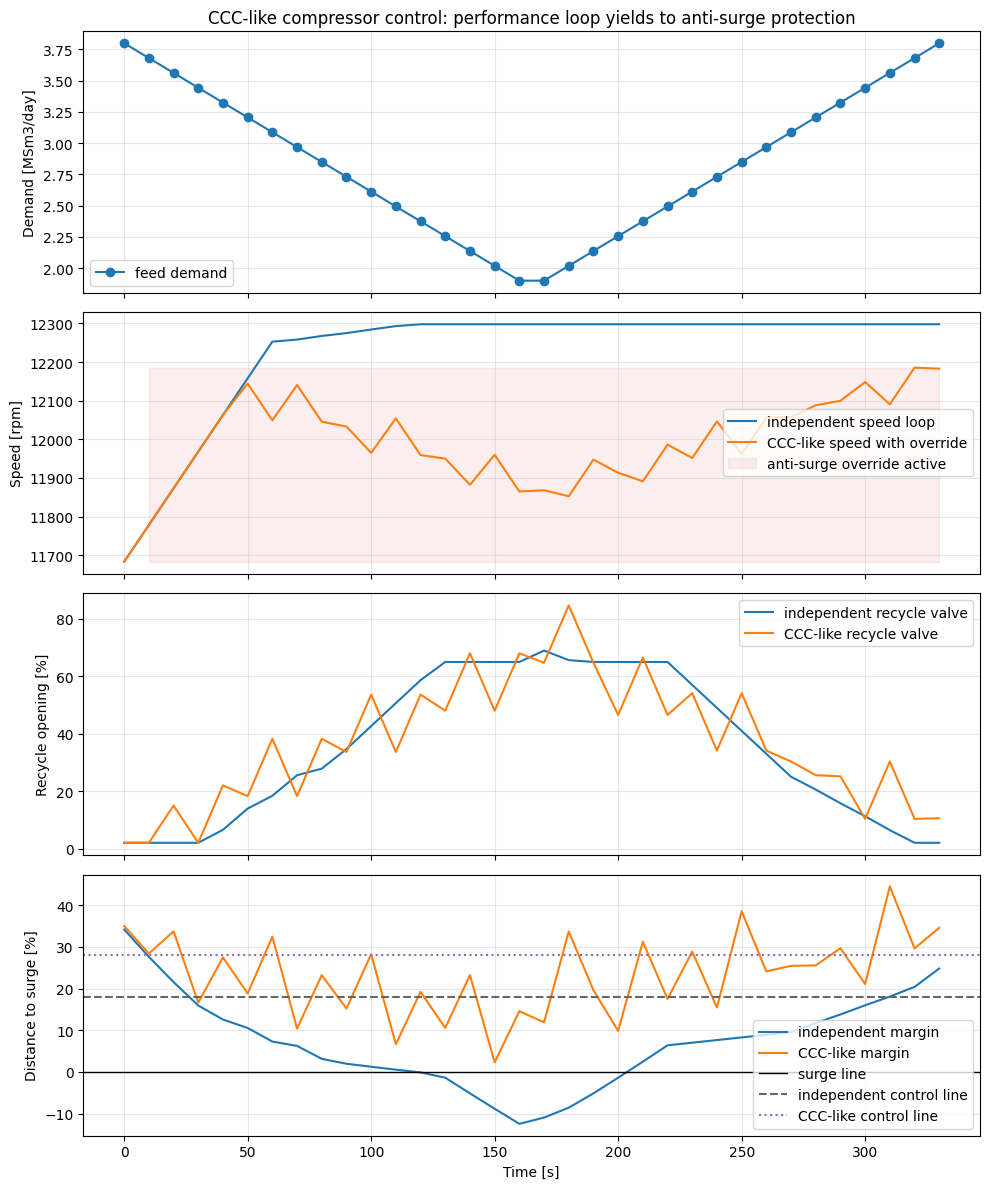

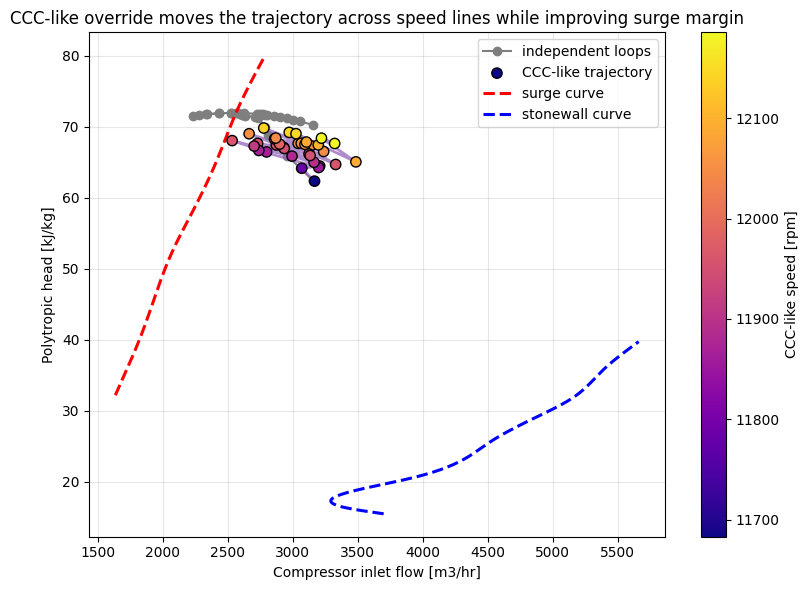

In [14]:
def simulate_ccc_like_compressor_control(coordinated=True):
    pressure_setpoint_bara = 90.0
    surge_control_margin = 0.32 if coordinated else 0.18
    minimum_speed = 10453.0
    maximum_speed = 12298.0
    maximum_speed_step = 95.0
    maximum_valve_step = 20.0 if coordinated else 8.0
    maximum_recycle_MSm3_day = 2.20 if coordinated else 1.25
    pressure_gain = 48.0
    pressure_integral_gain = 0.12
    anti_surge_gain = 360.0 if coordinated else 220.0

    speed = DESIGN_SPEED
    speed_integral = 0.0
    recycle_opening = 2.0
    history = []
    demand_schedule = list(np.r_[np.linspace(3.8, 1.9, 17), np.linspace(1.9, 3.8, 17)])

    for step, demand in enumerate(demand_schedule):
        recycle_flow = maximum_recycle_MSm3_day * recycle_opening / 100.0
        case = run_mapped_compressor_case(
            feed_flow_MSm3_day=float(demand + recycle_flow),
            speed=float(speed),
            suction_p_bara=SUCTION_P_BARA,
        )

        pressure = case["outlet_pressure_bara"]
        margin = case["surge_margin_pct"] / 100.0
        pressure_error = pressure_setpoint_bara - pressure
        anti_surge_error = surge_control_margin - margin
        anti_surge_active = anti_surge_error > 0.0 or recycle_opening > 5.0

        target_recycle_opening = 2.0
        if anti_surge_error > 0.0:
            target_recycle_opening = 2.0 + anti_surge_gain * anti_surge_error
        if coordinated and margin < 0.12:
            target_recycle_opening = max(target_recycle_opening, 85.0)
        elif margin < 0.03:
            target_recycle_opening = max(target_recycle_opening, 65.0)
        target_recycle_opening = float(np.clip(target_recycle_opening, 2.0, 100.0))

        if coordinated and anti_surge_active and pressure_error > 0.0:
            # Anti-surge override priority: do not wind up speed demand while recycle protects the machine.
            effective_integral = speed_integral
            speed_runback = 4.0 * recycle_opening + 900.0 * max(anti_surge_error, 0.0)
        else:
            speed_integral += pressure_error * 10.0
            effective_integral = speed_integral
            speed_runback = 0.0

        unconstrained_speed_target = (
            DESIGN_SPEED
            + pressure_gain * pressure_error
            + pressure_integral_gain * effective_integral
            - speed_runback
        )
        target_speed = float(np.clip(unconstrained_speed_target, minimum_speed, maximum_speed))

        new_speed = speed + float(np.clip(target_speed - speed, -maximum_speed_step, maximum_speed_step))
        new_recycle_opening = recycle_opening + float(
            np.clip(target_recycle_opening - recycle_opening, -maximum_valve_step, maximum_valve_step)
        )

        history.append({
            "time_s": float(step * 10.0),
            "demand_MSm3_day": float(demand),
            "recycle_flow_MSm3_day": float(recycle_flow),
            "recycle_opening_pct": float(recycle_opening),
            "target_recycle_opening_pct": float(target_recycle_opening),
            "speed_rpm": float(speed),
            "target_speed_rpm": float(target_speed),
            "outlet_pressure_bara": float(pressure),
            "pressure_error_bara": float(pressure_error),
            "surge_margin_pct": float(case["surge_margin_pct"]),
            "anti_surge_active": bool(anti_surge_active),
            "compressor_flow_m3hr": float(case["flow_m3hr"]),
            "head_kJkg": float(case["head_kJkg"]),
            "chart": case["chart"],
        })

        speed = new_speed
        recycle_opening = new_recycle_opening

    return history


independent_history = simulate_ccc_like_compressor_control(coordinated=False)
ccc_history = simulate_ccc_like_compressor_control(coordinated=True)


def trace(history, key):
    return np.array([row[key] for row in history], dtype=float)


time_ccc = trace(ccc_history, "time_s")
demand_ccc = trace(ccc_history, "demand_MSm3_day")
independent_speed = trace(independent_history, "speed_rpm")
ccc_speed = trace(ccc_history, "speed_rpm")
independent_recycle = trace(independent_history, "recycle_opening_pct")
ccc_recycle = trace(ccc_history, "recycle_opening_pct")
independent_margin = trace(independent_history, "surge_margin_pct")
ccc_margin = trace(ccc_history, "surge_margin_pct")
independent_pressure = trace(independent_history, "outlet_pressure_bara")
ccc_pressure = trace(ccc_history, "outlet_pressure_bara")
ccc_active = np.array([row["anti_surge_active"] for row in ccc_history], dtype=bool)

print("Independent loops:")
print(f"  speed range             : {independent_speed.min():.0f} to {independent_speed.max():.0f} rpm")
print(f"  max recycle opening     : {independent_recycle.max():.1f} %")
print(f"  minimum surge margin    : {independent_margin.min():.1f} %")
print("CCC-like coordinated loops:")
print(f"  speed range             : {ccc_speed.min():.0f} to {ccc_speed.max():.0f} rpm")
print(f"  max recycle opening     : {ccc_recycle.max():.1f} %")
print(f"  minimum surge margin    : {ccc_margin.min():.1f} %")
print(f"  anti-surge override time: {100.0 * ccc_active.mean():.1f} % of trajectory")

assert np.isfinite(ccc_speed).all()
assert np.isfinite(ccc_margin).all()
assert ccc_recycle.max() > 5.0
assert ccc_speed.max() - ccc_speed.min() > 100.0
assert ccc_margin.min() > independent_margin.min()

fig, ax = plt.subplots(4, 1, figsize=(10, 12), sharex=True)
ax[0].plot(time_ccc, demand_ccc, marker="o", color="tab:blue", label="feed demand")
ax[0].set_ylabel("Demand [MSm3/day]")
ax[0].set_title("CCC-like compressor control: performance loop yields to anti-surge protection")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(time_ccc, independent_speed, label="independent speed loop")
ax[1].plot(time_ccc, ccc_speed, label="CCC-like speed with override")
ax[1].fill_between(time_ccc, ccc_speed.min(), ccc_speed.max(), where=ccc_active, color="tab:red", alpha=0.08, label="anti-surge override active")
ax[1].set_ylabel("Speed [rpm]")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(time_ccc, independent_recycle, label="independent recycle valve")
ax[2].plot(time_ccc, ccc_recycle, label="CCC-like recycle valve")
ax[2].set_ylabel("Recycle opening [%]")
ax[2].legend()
ax[2].grid(True, alpha=0.3)

ax[3].plot(time_ccc, independent_margin, label="independent margin")
ax[3].plot(time_ccc, ccc_margin, label="CCC-like margin")
ax[3].axhline(0.0, color="k", lw=1, label="surge line")
ax[3].axhline(18.0, color="0.4", ls="--", label="independent control line")
ax[3].axhline(28.0, color="tab:purple", ls=":", label="CCC-like control line")
ax[3].set_xlabel("Time [s]")
ax[3].set_ylabel("Distance to surge [%]")
ax[3].legend()
ax[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
independent_flow = trace(independent_history, "compressor_flow_m3hr")
independent_head = trace(independent_history, "head_kJkg")
ccc_flow = trace(ccc_history, "compressor_flow_m3hr")
ccc_head = trace(ccc_history, "head_kJkg")
ax.plot(independent_flow, independent_head, "o-", color="tab:gray", label="independent loops")
points = ax.scatter(ccc_flow, ccc_head, c=ccc_speed, cmap="plasma", s=55, edgecolor="k", label="CCC-like trajectory", zorder=4)
ax.plot(ccc_flow, ccc_head, color="tab:purple", lw=2.0, alpha=0.75)
plot_chart = ccc_history[-1]["chart"]
surge_q, surge_h = smooth_limit(plot_chart.getSurgeCurve(), "surge")
wall_q, wall_h = smooth_limit(plot_chart.getStoneWallCurve(), "stonewall")
ax.plot(surge_q, surge_h, "r--", lw=2.2, label="surge curve")
ax.plot(wall_q, wall_h, "b--", lw=2.2, label="stonewall curve")
plt.colorbar(points, ax=ax, label="CCC-like speed [rpm]")
ax.set_xlabel("Compressor inlet flow [m3/hr]")
ax.set_ylabel("Polytropic head [kJ/kg]")
ax.set_title("CCC-like override moves the trajectory across speed lines while improving surge margin")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Colab-style recycle loop with the Java `AntiSurgeController`

This section uses the same physical topology as the Colab-style anti-surge loop: a mapped compressor discharges to a `Splitter`, the recycle branch passes through a `ThrottlingValve`, a `Recycle` block sends that stream back to a recycle stream, and a `Mixer` combines feed plus recycle before the suction cooler and compressor.

The only control change is that the recycle valve is now driven by the typed Java `AntiSurgeController` instead of the generic controller block. The controller reads the compressor map distance-to-surge and writes the valve opening. The valve opening changes the effective valve Kv/Cv in the recycle branch, while the recycle block closes the material loop back to the suction mixer.

Colab-loop minimum distance to surge : -0.2306
Colab-loop maximum valve opening     :  100.0 %
Colab-loop maximum recycle flow      :  12806 kg/hr
Final distance to surge              :  0.5183


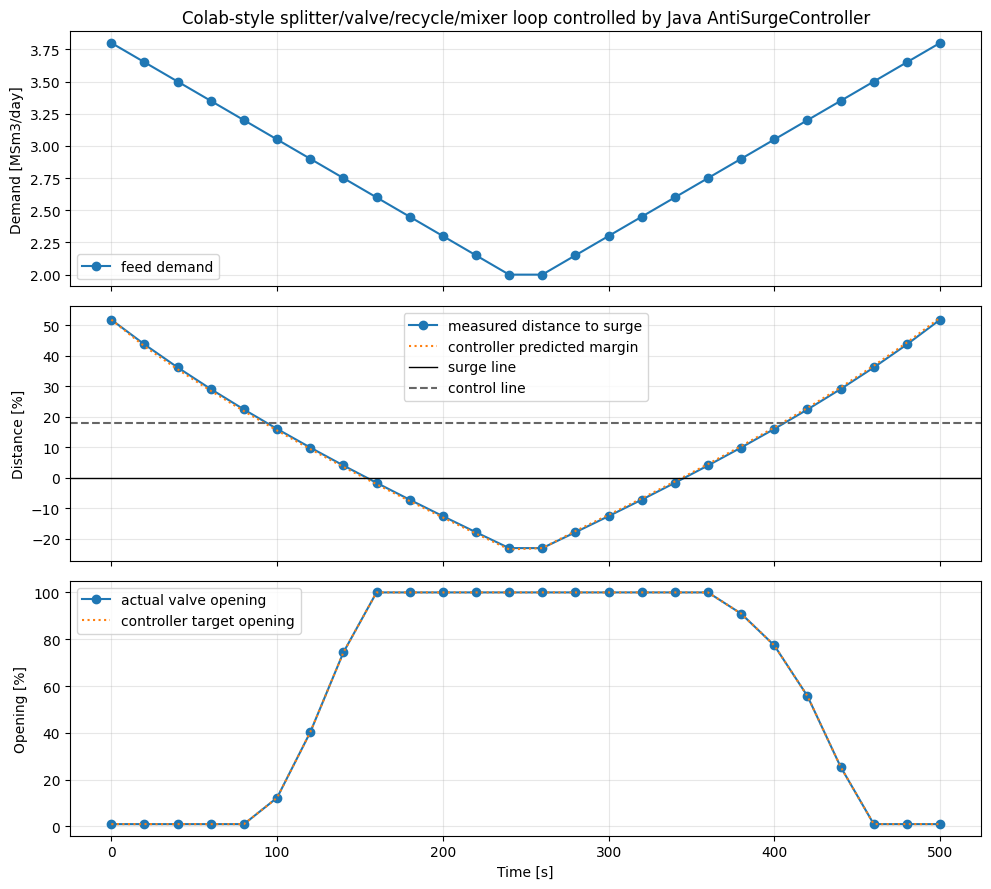

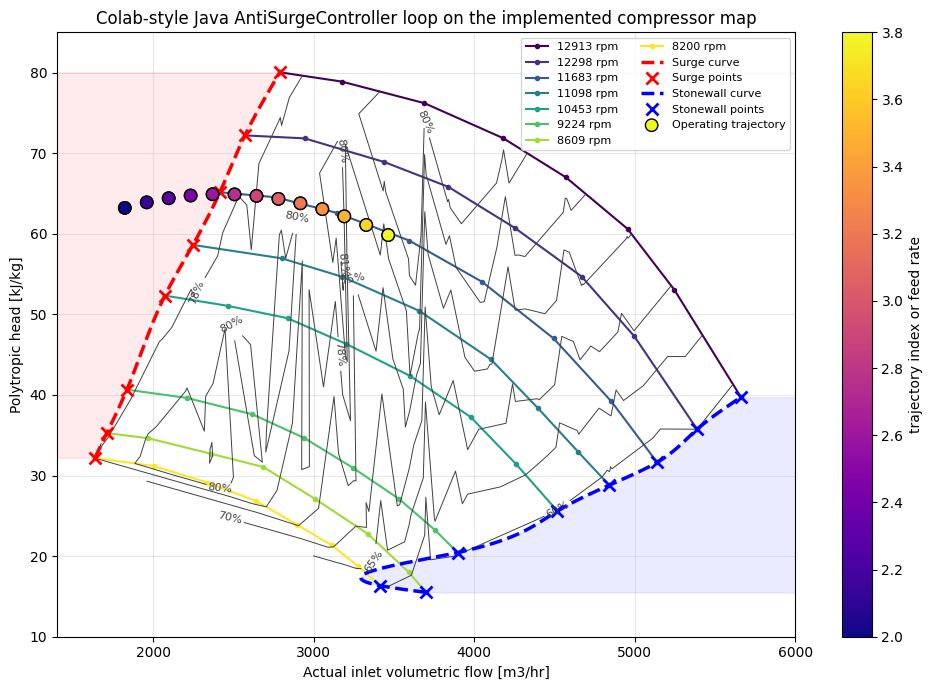

In [15]:
AntiSurgeController = ns.JClass("neqsim.process.controllerdevice.AntiSurgeController")
JavaUUID = ns.JClass("java.util.UUID")


def build_colab_style_antisurge_loop(feed_flow_MSm3_day=3.8):
    """Build the splitter-valve-recycle-mixer loop used in the Colab-style example."""
    process = ProcessSystem()

    feed = Stream("java-controller feed gas", make_gas(feed_flow_MSm3_day, t_C=24.0, p_bara=SUCTION_P_BARA))
    feed.run()
    process.add(feed)

    recycle_stream = Stream("java-controller recycle stream", feed.getThermoSystem().clone())
    recycle_stream.setFlowRate(0.05, "MSm3/day")
    recycle_stream.run()
    process.add(recycle_stream)

    mixer = Mixer("java-controller suction mixer")
    mixer.addStream(feed)
    mixer.addStream(recycle_stream)
    mixer.run()
    process.add(mixer)

    suction_cooler = Cooler("java-controller suction cooler")
    suction_cooler.setInletStream(mixer.getOutletStream())
    suction_cooler.setOutTemperature(24.0, "C")
    suction_cooler.run()
    process.add(suction_cooler)

    compressor = Compressor("java-controller mapped compressor", suction_cooler.getOutletStream())
    compressor.setOutletPressure(95.0, "bara")
    install_good_compressor_map(compressor)
    compressor.run()
    process.add(compressor)

    splitter = Splitter("java-controller anti-surge splitter", compressor.getOutletStream(), 2)
    splitter.setSplitFactors([0.90, 0.10])
    splitter.run()
    process.add(splitter)

    recycle_valve = ThrottlingValve("java-controller anti-surge valve", splitter.getSplitStream(1))
    recycle_valve.setOutletPressure(SUCTION_P_BARA, "bara")
    recycle_valve.setMinimumValveOpening(1.0)
    recycle_valve.setPercentValveOpening(2.0)
    recycle_valve.run()
    process.add(recycle_valve)

    recycle = Recycle("java-controller anti-surge recycle")
    recycle.addStream(recycle_valve.getOutletStream())
    recycle.setOutletStream(recycle_stream)
    recycle.setTolerance(1.0e-3)
    recycle.run()
    process.add(recycle)

    controller = AntiSurgeController(
        "java-controller anti-surge controller",
        compressor,
        recycle_valve,
    )
    controller.setActive(True)
    controller.setSurgeMarginSetPoint(0.18)
    controller.setProportionalGain(260.0)
    controller.setIntegralTime(45.0)
    controller.setOpeningRange(1.0, 100.0)
    controller.setEmergencyAction(0.03, 65.0)
    controller.setActuatorDynamics(30.0, 1.5)
    controller.setPredictiveActionEnabled(True)
    controller.setPredictionHorizon(8.0)
    controller.setMarginRateFilterTime(4.0)
    recycle_valve.setController(controller)

    process.run()
    return {
        "process": process,
        "feed": feed,
        "recycle_stream": recycle_stream,
        "mixer": mixer,
        "compressor": compressor,
        "splitter": splitter,
        "recycle_valve": recycle_valve,
        "recycle": recycle,
        "controller": controller,
    }


def run_controller_moves(model, dt_s=5.0, moves=4):
    """Let the Java anti-surge controller move the recycle valve, then solve the recycle loop."""
    controller = model["controller"]
    recycle_valve = model["recycle_valve"]
    process = model["process"]
    for _ in range(moves):
        controller.runTransient(recycle_valve.getPercentValveOpening(), dt_s, JavaUUID.randomUUID())
        process.run()


colab_loop = build_colab_style_antisurge_loop()
loop_process = colab_loop["process"]
loop_feed = colab_loop["feed"]
loop_recycle_stream = colab_loop["recycle_stream"]
loop_compressor = colab_loop["compressor"]
loop_recycle_valve = colab_loop["recycle_valve"]
loop_controller = colab_loop["controller"]

# Plant-like sequence: feed demand falls toward the surge boundary and then recovers.
demand_schedule = list(np.r_[np.linspace(3.8, 2.0, 13), np.linspace(2.0, 3.8, 13)])
colab_loop_history = []

for step, demand in enumerate(demand_schedule):
    loop_feed.setFlowRate(float(demand), "MSm3/day")
    loop_process.run()
    run_controller_moves(colab_loop, dt_s=5.0, moves=4)

    colab_loop_history.append({
        "time_s": float(step * 20.0),
        "demand_MSm3_day": float(demand),
        "surge_margin": loop_compressor.getDistanceToSurge(),
        "predicted_margin": loop_controller.getPredictedMargin(),
        "valve_opening_pct": loop_recycle_valve.getPercentValveOpening(),
        "target_opening_pct": loop_controller.getTargetValveOpening(),
        "recycle_flow_kg_hr": loop_recycle_stream.getFlowRate("kg/hr"),
        "compressor_flow_m3hr": loop_compressor.getInletStream().getFlowRate("m3/hr"),
        "head_kJkg": loop_compressor.getPolytropicFluidHead(),
    })

loop_time = np.array([row["time_s"] for row in colab_loop_history])
loop_demand = np.array([row["demand_MSm3_day"] for row in colab_loop_history])
loop_margin = np.array([row["surge_margin"] for row in colab_loop_history], dtype=float)
loop_predicted = np.array([row["predicted_margin"] for row in colab_loop_history], dtype=float)
loop_opening = np.array([row["valve_opening_pct"] for row in colab_loop_history], dtype=float)
loop_target = np.array([row["target_opening_pct"] for row in colab_loop_history], dtype=float)
loop_recycle_flow = np.array([row["recycle_flow_kg_hr"] for row in colab_loop_history], dtype=float)
loop_flow = np.array([row["compressor_flow_m3hr"] for row in colab_loop_history], dtype=float)
loop_head = np.array([row["head_kJkg"] for row in colab_loop_history], dtype=float)

loop_min_margin = float(np.nanmin(loop_margin))
loop_max_opening = float(np.nanmax(loop_opening))
loop_max_recycle = float(np.nanmax(loop_recycle_flow))

print(f"Colab-loop minimum distance to surge : {loop_min_margin: .4f}")
print(f"Colab-loop maximum valve opening     : {loop_max_opening: .1f} %")
print(f"Colab-loop maximum recycle flow      : {loop_max_recycle: .0f} kg/hr")
print(f"Final distance to surge              : {loop_margin[-1]: .4f}")

assert np.isfinite(loop_margin).all()
assert np.isfinite(loop_recycle_flow).all()
assert loop_max_opening > 5.0
assert loop_margin[-1] > 0.0

fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
ax[0].plot(loop_time, loop_demand, marker="o", label="feed demand")
ax[0].set_ylabel("Demand [MSm3/day]")
ax[0].set_title("Colab-style splitter/valve/recycle/mixer loop controlled by Java AntiSurgeController")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(loop_time, loop_margin * 100.0, marker="o", label="measured distance to surge")
ax[1].plot(loop_time, loop_predicted * 100.0, ls=":", label="controller predicted margin")
ax[1].axhline(0.0, color="k", lw=1, label="surge line")
ax[1].axhline(loop_controller.getSurgeMarginSetPoint() * 100.0, color="0.4", ls="--", label="control line")
ax[1].set_ylabel("Distance [%]")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(loop_time, loop_opening, marker="o", label="actual valve opening")
ax[2].plot(loop_time, loop_target, ls=":", label="controller target opening")
ax[2].set_xlabel("Time [s]")
ax[2].set_ylabel("Opening [%]")
ax[2].legend()
ax[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

loop_trajectory = [
    {"flow_m3hr": float(q), "head_kJkg": float(h), "color": float(d)}
    for q, h, d in zip(loop_flow, loop_head, loop_demand)
    if np.isfinite(q) and np.isfinite(h)
]
plot_compressor_map(
    loop_compressor.getCompressorChart(),
    loop_trajectory,
    "Colab-style Java AntiSurgeController loop on the implemented compressor map",
)
plt.show()

## 8. Java predictive anti-surge supervision

The Java `AntiSurgeController` now has an optional predictive layer on top of the existing PI law. With the default settings it behaves like the earlier controller, but when enabled it estimates where the distance-to-surge will be after a short prediction horizon:

$$
m_\mathrm{pred} = m + \dot{m}_f \Delta t_\mathrm{pred}
$$

where $m$ is the measured distance to surge and $\dot{m}_f$ is a filtered margin rate. The controller then acts on the smaller of the measured and predicted margin. This makes the recycle valve start moving before the operating point has already reached the surge-control line.

The demonstration below uses the Java `AntiSurgeDynamicBenchmark`. Both cases use the same disturbance, valve rate limit, and actuator lag. The only difference is that the second case enables `setPredictiveActionEnabled(true)`, `setPredictionHorizon(...)`, and `setMarginRateFilterTime(...)` on the Java controller.

Java PI minimum distance to surge          : -0.0110
Java predictive minimum distance to surge  :  0.0849
Java PI maximum recycle opening            :  58.5 %
Java predictive maximum recycle opening    :  40.8 %
Improvement in minimum margin              :  9.6 percentage points


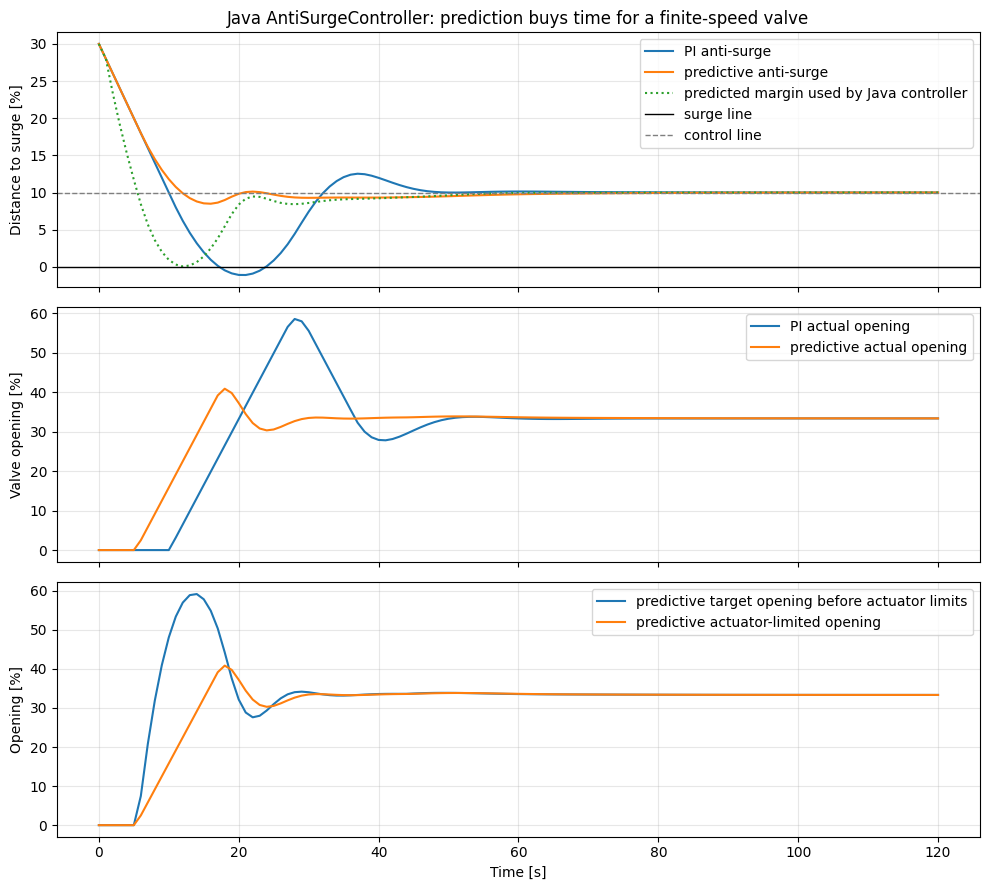

In [16]:
AntiSurgeDynamicBenchmark = ns.JClass("neqsim.process.util.scenario.AntiSurgeDynamicBenchmark")


def run_java_anti_surge_benchmark(predictive=False):
    """Run the Java anti-surge benchmark with identical actuator limits."""
    benchmark = AntiSurgeDynamicBenchmark()
    controller = benchmark.getController()
    controller.setActuatorDynamics(10.0, 3.0)  # valve stroke limit [%/s], actuator lag [s]
    if predictive:
        controller.setPredictiveActionEnabled(True)
        controller.setPredictionHorizon(8.0)
        controller.setMarginRateFilterTime(5.0)
    benchmark.run(True)

    margin = np.array(benchmark.getSurgeMarginTrace(), dtype=float)
    valve = np.array(benchmark.getValveOpeningTrace(), dtype=float)
    target = np.array(benchmark.getTargetValveOpeningTrace(), dtype=float)
    predicted = np.array(benchmark.getPredictedSurgeMarginTrace(), dtype=float)
    time = np.arange(len(margin), dtype=float)
    return {
        "benchmark": benchmark,
        "time_s": time,
        "margin": margin,
        "valve_opening_pct": valve,
        "target_opening_pct": target,
        "predicted_margin": predicted,
    }


pi_case = run_java_anti_surge_benchmark(predictive=False)
predictive_case = run_java_anti_surge_benchmark(predictive=True)

pi_min_margin = float(pi_case["margin"].min())
predictive_min_margin = float(predictive_case["margin"].min())
pi_max_opening = float(pi_case["valve_opening_pct"].max())
predictive_max_opening = float(predictive_case["valve_opening_pct"].max())

print(f"Java PI minimum distance to surge          : {pi_min_margin: .4f}")
print(f"Java predictive minimum distance to surge  : {predictive_min_margin: .4f}")
print(f"Java PI maximum recycle opening            : {pi_max_opening: .1f} %")
print(f"Java predictive maximum recycle opening    : {predictive_max_opening: .1f} %")
print(f"Improvement in minimum margin              : {(predictive_min_margin - pi_min_margin) * 100.0: .1f} percentage points")

assert pi_min_margin < 0.0, "With actuator limits, current-margin PI should briefly cross the surge line."
assert predictive_min_margin > 0.0, "Predictive supervision should keep positive margin."
assert predictive_min_margin > pi_min_margin, "Predictive supervision should improve the minimum margin."

fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
ax[0].plot(pi_case["time_s"], pi_case["margin"] * 100.0, label="PI anti-surge")
ax[0].plot(
    predictive_case["time_s"],
    predictive_case["margin"] * 100.0,
    label="predictive anti-surge",
)
ax[0].plot(
    predictive_case["time_s"],
    predictive_case["predicted_margin"] * 100.0,
    color="tab:green",
    ls=":",
    label="predicted margin used by Java controller",
)
ax[0].axhline(0.0, color="k", lw=1, label="surge line")
ax[0].axhline(10.0, color="tab:gray", ls="--", lw=1, label="control line")
ax[0].set_ylabel("Distance to surge [%]")
ax[0].set_title("Java AntiSurgeController: prediction buys time for a finite-speed valve")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(pi_case["time_s"], pi_case["valve_opening_pct"], label="PI actual opening")
ax[1].plot(
    predictive_case["time_s"],
    predictive_case["valve_opening_pct"],
    label="predictive actual opening",
)
ax[1].set_ylabel("Valve opening [%]")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(
    predictive_case["time_s"],
    predictive_case["target_opening_pct"],
    label="predictive target opening before actuator limits",
)
ax[2].plot(
    predictive_case["time_s"],
    predictive_case["valve_opening_pct"],
    label="predictive actuator-limited opening",
)
ax[2].set_xlabel("Time [s]")
ax[2].set_ylabel("Opening [%]")
ax[2].legend()
ax[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. From steady state to dynamic anti-surge simulation

The recommended workflow is to solve the compressor recycle system in steady state first, then use that converged point as the initial condition for a transient run. The important change is not the topology; it is the simulation mode and the controller timing:

1. Build the process with the same recycle branch you want in the dynamic model.
2. Run `process.run()` until the steady-state flows, pressures, and compressor map point are consistent.
3. Set physically relevant holdups and valve openings from that steady-state point.
4. Switch equipment with inventory or actuator dynamics to `setCalculateSteadyState(False)`.
5. Attach the `AntiSurgeController` to the recycle valve and advance with `process.runTransient(dt)`.

The short example below uses the same mapped compressor and recycle topology as the previous section, but it explicitly reports the steady-state initial point before starting the dynamic disturbance.

Steady-state initial point
  compressor_flow_m3hr    :   3646.912
  head_kJkg               :     57.886
  speed_rpm               :  11683.000
  surge_margin_pct        :     63.805
  recycle_opening_pct     :      2.000
  discharge_pressure_bara :     73.962

Dynamic response from the steady-state initial point
  minimum distance to surge : -30.39 %
  maximum recycle opening   :   93.2 %
  maximum recycle flow      :   3369 m3/hr


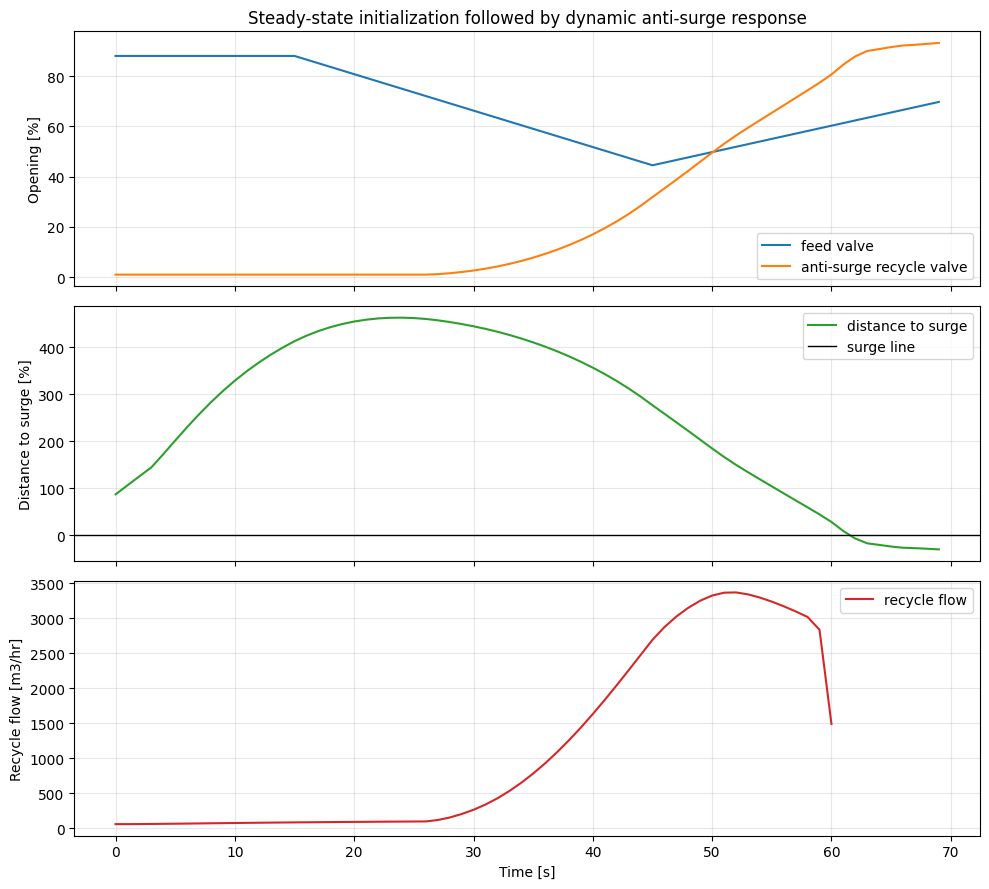

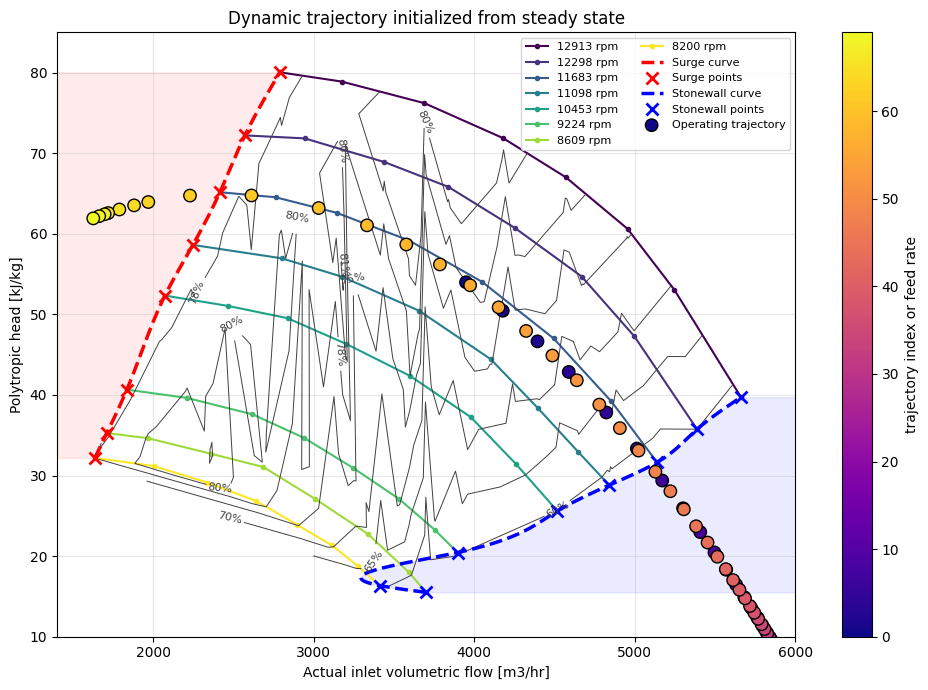

In [17]:
steady_to_dynamic = build_dynamic_antisurge_process()
steady_process = steady_to_dynamic["process"]
steady_compressor = steady_to_dynamic["compressor"]
steady_feed_valve = steady_to_dynamic["feed_valve"]
steady_recycle_valve = steady_to_dynamic["recycle_valve"]
steady_surge_monitor = steady_to_dynamic["surge_monitor"]

# These are the equipment items that carry the steady/dynamic mode switch in this example.
dynamic_unit_names = [
    "dynamic inlet valve",
    "dynamic suction separator",
    "dynamic mapped compressor",
    "dynamic after cooler",
    "dynamic discharge separator",
    "dynamic anti-surge splitter",
    "dynamic anti-surge valve",
    "dynamic outlet valve",
]

# Step 1: solve the model as a steady-state initial condition.
# The recycle topology already exists; in steady state the controller timing is not used.
for unit_name in dynamic_unit_names:
    unit = steady_process.getUnit(unit_name)
    if unit is not None:
        unit.setCalculateSteadyState(True)

steady_feed_valve.setPercentValveOpening(88.0)
steady_recycle_valve.setPercentValveOpening(2.0)
steady_process.run()

initial_point = {
    "compressor_flow_m3hr": steady_compressor.getInletStream().getFlowRate("m3/hr"),
    "head_kJkg": steady_compressor.getPolytropicFluidHead(),
    "speed_rpm": steady_compressor.getSpeed(),
    "surge_margin_pct": steady_surge_monitor.getMeasuredValue("distance to surge") * 100.0,
    "recycle_opening_pct": steady_recycle_valve.getPercentValveOpening(),
    "discharge_pressure_bara": steady_compressor.getOutletStream().getPressure("bara"),
}

print("Steady-state initial point")
for key, value in initial_point.items():
    print(f"  {key:24s}: {value:10.3f}")

# Step 2: switch the already-converged equipment to dynamic mode.
# This is the handoff point from steady-state initialization to transient simulation.
for unit_name in dynamic_unit_names:
    unit = steady_process.getUnit(unit_name)
    if unit is not None:
        unit.setCalculateSteadyState(False)

# Step 3: run a disturbance. The compressor starts from the steady-state point above.
steady_process.setTimeStep(1.0)
transition_history = []
for step in range(70):
    time_s = float(step)
    if step < 15:
        opening = 88.0
    elif step < 45:
        opening = 88.0 - 1.45 * (step - 15)
    else:
        opening = 44.5 + 1.05 * (step - 45)
    steady_feed_valve.setPercentValveOpening(float(np.clip(opening, 42.0, 88.0)))
    steady_process.runTransient()

    transition_history.append({
        "time_s": time_s,
        "feed_opening_pct": steady_feed_valve.getPercentValveOpening(),
        "recycle_opening_pct": steady_recycle_valve.getPercentValveOpening(),
        "surge_margin_pct": steady_surge_monitor.getMeasuredValue("distance to surge") * 100.0,
        "recycle_flow_m3hr": steady_recycle_valve.getOutletStream().getFlowRate("m3/hr"),
        "compressor_flow_m3hr": steady_compressor.getInletStream().getFlowRate("m3/hr"),
        "head_kJkg": steady_compressor.getPolytropicFluidHead(),
        "speed_rpm": steady_compressor.getSpeed(),
    })

transition_time = np.array([row["time_s"] for row in transition_history])
transition_feed_opening = np.array([row["feed_opening_pct"] for row in transition_history])
transition_recycle_opening = np.array([row["recycle_opening_pct"] for row in transition_history])
transition_margin = np.array([row["surge_margin_pct"] for row in transition_history])
transition_recycle_flow = np.array([row["recycle_flow_m3hr"] for row in transition_history])
transition_flow = np.array([row["compressor_flow_m3hr"] for row in transition_history])
transition_head = np.array([row["head_kJkg"] for row in transition_history])

print("\nDynamic response from the steady-state initial point")
print(f"  minimum distance to surge : {np.nanmin(transition_margin):6.2f} %")
print(f"  maximum recycle opening   : {np.nanmax(transition_recycle_opening):6.1f} %")
print(f"  maximum recycle flow      : {np.nanmax(transition_recycle_flow):6.0f} m3/hr")

fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)
ax[0].plot(transition_time, transition_feed_opening, label="feed valve")
ax[0].plot(transition_time, transition_recycle_opening, label="anti-surge recycle valve")
ax[0].set_ylabel("Opening [%]")
ax[0].set_title("Steady-state initialization followed by dynamic anti-surge response")
ax[0].legend()
ax[0].grid(True, alpha=0.3)

ax[1].plot(transition_time, transition_margin, color="tab:green", label="distance to surge")
ax[1].axhline(0.0, color="k", lw=1, label="surge line")
ax[1].set_ylabel("Distance to surge [%]")
ax[1].legend()
ax[1].grid(True, alpha=0.3)

ax[2].plot(transition_time, transition_recycle_flow, color="tab:red", label="recycle flow")
ax[2].set_xlabel("Time [s]")
ax[2].set_ylabel("Recycle flow [m3/hr]")
ax[2].legend()
ax[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

transition_points = [
    {"flow_m3hr": float(q), "head_kJkg": float(h), "color": float(t)}
    for q, h, t in zip(transition_flow, transition_head, transition_time)
    if np.isfinite(q) and np.isfinite(h)
]
plot_compressor_map(
    steady_compressor.getCompressorChart(),
    transition_points,
    "Dynamic trajectory initialized from steady state",
)
plt.show()


## What changed compared with the simple dynamic compressor notebook

- The compressor map is explicit data, not a one-point generated placeholder.
- The same map is used for simulation, diagnostics, and plotting.
- The surge curve is installed with `getSurgeCurve().setCurve(...)` and the stonewall curve with `getStoneWallCurve().setCurve(...)`.
- Dynamic examples plot their operating trajectories directly on the implemented map.
- The anti-surge sweep uses `AntiSurgeCalculator` and a recycle loop so low-demand cases are handled by moving the suction operating point back toward the surge boundary.
- The dynamic anti-surge example uses a ramped inlet-valve closure, a pressure-coupled recycle valve, and assertions on minimum distance-to-surge and finite recycle flow so the GOOD-map transient remains regression-checkable.
- The final example shows the practical handoff from a converged steady-state recycle model to a dynamic anti-surge run: solve first, set timestep, switch supported equipment to transient mode, keep the recycle block algebraic, then run process.runTransient().